# Анализ пространственно-временной динамики регистраций лебедей в Северной Америке.


## Введение

В работе используются реальные данные о наблюдениях за лебедями в Северной Америке. Нужно очистить эти данные, добавить информацию о температуре и плотности населения, разделить наблюдения по сезонам, выделить географические зоны и проверить, смещается ли ареал со временем.

*Цель*

Оценить временные изменения широты регистраций трёх видов лебедей в разных географических зонах и сезонах. Исследовать статистические связи широты регистраций с температурой и плотностью населения. Учесть, что изменения наблюдательной сети могут влиять на полученные результаты.

*Задачи*

1. Загрузить и очистить данные о наблюдениях за лебедями.
2. Добавить данные о плотности населения и температуре.
3. Провести кластерный анализ и выделить 5 географических зон.
4. Учесть сезонность (зимовка и гнездование).
5. Провести статистический анализ: тренды, корреляции, сравнение групп.
6. Построить минимум 4 графика.
7. Сформулировать выводы.

*Данные*

- `short.csv` — наблюдения за лебедями (6 видов, 1980–2024).
- `US_CA.csv` — плотность населения штатов США и провинций Канады.
- `us_state_temperatures.csv` — температуры по штатам США.
- `canada_temperatures.csv` — температуры по провинциям Канады.

*Инструменты*

Python, библиотеки: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `sklearn`, `statsmodels`.

## Загрузка библиотек

In [1]:
# Базовые библиотеки
import pandas as pd
import numpy as np
import re
from pathlib import Path

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import Button, HTML, Output, Layout, VBox, HBox
from IPython.display import display
import time

# Статистика
from scipy.stats import linregress, kruskal, mannwhitneyu, pearsonr, spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from itertools import combinations


# Машинное обучение
from sklearn.preprocessing import StandardScaler

# Регрессия
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Настройка стиля графиков
sns.set_style('whitegrid')

# Чтобы pandas показывал больше столбцов
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

In [2]:
!pip install ipywidgets

## Загрузка данных

In [3]:
def find_dir_with(filenames, start: Path = None, max_depth: int = 6) -> Path:
    """Возвращает первую папку, где есть все указанные файлы."""
    start = Path(start or Path.cwd()).resolve()

    for folder in [start, *start.parents][: max_depth + 1]:
        if all((folder / f).is_file() for f in filenames):
            return folder

    for folder in start.rglob("*"):
        if folder.is_dir() and all((folder / f).is_file() for f in filenames):
            return folder

    raise FileNotFoundError(f"Папка с файлами {filenames} не найдена")


RAW_FILES = ["short.csv", "US_CA.csv", "us_state_temperatures.csv", "canada_temperatures.csv"]
RAW_DIR = find_dir_with(RAW_FILES)

data            = pd.read_csv(RAW_DIR / "short.csv")
df_us_ca        = pd.read_csv(RAW_DIR / "US_CA.csv")
us_temperatures = pd.read_csv(RAW_DIR / "us_state_temperatures.csv")
ca_temperatures = pd.read_csv(RAW_DIR / "canada_temperatures.csv")

## Знакомство с датасетами

### Функция обзора

In [4]:
# Функция обзора
def explore_dataset(df):
    """
    Общий обзор датасета:
    - размер
    - первые строки
    - типы данных + пропуски
    - описательная статистика
    - дубликаты
    - уникальные значения по каждому столбцу
    """
    # Размер
    print("Размер (строки, столбцы):", df.shape)
    print()

    # Первые строки
    print("Первые строки:")
    display(df.head())
    print()

    # Типы данных + пропуски
    print("Типы данных и пропуски:")
    info_table = pd.DataFrame({
        'Тип данных': df.dtypes,
        'Непустых': df.notna().sum(),
        'Пропусков': df.isna().sum(),
        'Доля пропусков, %': (df.isna().sum() / len(df) * 100).round(2)
    })
    display(info_table)
    print()

    # Описательная статистика
    print("Описательная статистика:")
    display(df.describe(include='all'))
    print()

    # Дубликаты
    print("Полных дубликатов строк:", df.duplicated().sum())
    print()

    # Уникальные значения по каждому столбцу
    print("Уникальных значений по столбцам:")
    display(df.nunique().sort_values())
    print()

### Основной датасет data (short.csv)

In [5]:
explore_dataset(data)

Размер (строки, столбцы): (3489498, 22)

Первые строки:


,gbifID,basisOfRecord,recordedBy,eventDate,year,month,day,countryCode,stateProvince,locality,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,coordinatePrecision,infraspecificEpithet,taxonRank,datasetKey,elevation,elevationAccuracy,depth,depthAccuracy,species
0,938888072,HUMAN_OBSERVATION,obsr137539,2008-01-19,2008,1,19,US,Massachusetts,Provincetown Harbor--boat ramp on Commercial S...,42.041756,-70.193480,NaN,NaN,NaN,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,NaN,NaN,NaN,NaN,Cygnus olor
1,3511818940,HUMAN_OBSERVATION,obsr902368,2021-01-23,2021,1,23,US,Massachusetts,South Hadley Canal Park,42.222797,-72.608850,NaN,NaN,NaN,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,NaN,NaN,NaN,NaN,Cygnus olor
2,5474067204,HUMAN_OBSERVATION,obsr440493,2024-03-21,2024,3,21,US,New York,Marshlands Conservancy,40.953114,-73.701225,NaN,NaN,NaN,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,NaN,NaN,NaN,NaN,Cygnus olor
3,3264353040,HUMAN_OBSERVATION,obsr305952,2020-05-28,2020,5,28,CA,Ontario,Port Franks private beach (restricted access),43.231647,-81.911110,NaN,NaN,NaN,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,NaN,NaN,NaN,NaN,Cygnus olor
4,3630533474,HUMAN_OBSERVATION,obsr1312860,2021-09-09,2021,9,9,CA,Ontario,Niagara-on-the-Lake--Outlet Collection ponds,43.155900,-79.176960,NaN,NaN,NaN,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,NaN,NaN,NaN,NaN,Cygnus buccinator



Типы данных и пропуски:


,Тип данных,Непустых,Пропусков,"Доля пропусков, %"
gbifID,int64,3489498,0,0.0
basisOfRecord,object,3489498,0,0.0
recordedBy,object,3489498,0,0.0
eventDate,object,3489498,0,0.0
year,int64,3489498,0,0.0
month,int64,3489498,0,0.0
day,int64,3489498,0,0.0
countryCode,object,3489498,0,0.0
stateProvince,object,3489498,0,0.0
locality,object,3489494,4,0.0



Описательная статистика:


,gbifID,basisOfRecord,recordedBy,eventDate,year,month,day,countryCode,stateProvince,locality,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,coordinatePrecision,infraspecificEpithet,taxonRank,datasetKey,elevation,elevationAccuracy,depth,depthAccuracy,species
count,3.489498e+06,3489498,3489498,3489498,3.489498e+06,3.489498e+06,3.489498e+06,3489498,3489498,3489494,3.489498e+06,3.489498e+06,0.0,0.0,0.0,3489498,3489498,0.0,0.0,0.0,0.0,3489498
unique,NaN,1,133785,16045,NaN,NaN,NaN,9,80,326665,NaN,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,6
top,NaN,HUMAN_OBSERVATION,obsr280631,2024-05-11,NaN,NaN,NaN,US,Ontario,Tommy Thompson Park,NaN,NaN,NaN,NaN,NaN,SPECIES,4fa7b334-ce0d-4e88-aaae-2e0c138d049e,NaN,NaN,NaN,NaN,Cygnus olor
freq,NaN,3489498,6716,5162,NaN,NaN,NaN,2765869,517084,35545,NaN,NaN,NaN,NaN,NaN,3489498,3489498,NaN,NaN,NaN,NaN,1810815
mean,3.446432e+09,NaN,NaN,NaN,2.018632e+03,5.882609e+00,1.532224e+01,NaN,NaN,NaN,4.299199e+01,-8.759845e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.584873e+09,NaN,NaN,NaN,5.663563e+00,3.664935e+00,8.790792e+00,NaN,NaN,NaN,4.599620e+00,1.818097e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.328315e+08,NaN,NaN,NaN,1.980000e+03,1.000000e+00,1.000000e+00,NaN,NaN,NaN,1.797686e+01,-1.766638e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.115309e+09,NaN,NaN,NaN,2.016000e+03,3.000000e+00,8.000000e+00,NaN,NaN,NaN,4.073554e+01,-9.106323e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,3.574132e+09,NaN,NaN,NaN,2.020000e+03,5.000000e+00,1.500000e+01,NaN,NaN,NaN,4.239741e+01,-8.155203e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,4.750371e+09,NaN,NaN,NaN,2.022000e+03,1.000000e+01,2.300000e+01,NaN,NaN,NaN,4.404779e+01,-7.526015e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Полных дубликатов строк: 0

Уникальных значений по столбцам:


elevationAccuracy                      0
infraspecificEpithet                   0
coordinatePrecision                    0
coordinateUncertaintyInMeters          0
depth                                  0
depthAccuracy                          0
elevation                              0
basisOfRecord                          1
datasetKey                             1
taxonRank                              1
species                                6
countryCode                            9
month                                 12
day                                   31
year                                  45
stateProvince                         80
eventDate                          16045
recordedBy                        133785
locality                          326665
decimalLatitude                   327433
decimalLongitude                  331938
gbifID                           3489498
dtype: int64

#### Выводы по обзору `data`



- Размер: 3 489 498 строк, 22 столбца.
- Полных дубликатов нет.
- `gbifID` уникален для всех 3.5 млн записей — это хорошо.
- 6 видов, 9 стран, 80 штатов/провинций, 45 лет (1980–2024).
- В столбце `countryCode` чаще всего встречается `US` (2 765 869 записей), затем `CA` (517 084), потом `Ontario` (почему-то попал в `countryCode` — это уже аномалия), и ещё 6 значений.

Столбцы со 100% пропусков

Семь столбцов пустые полностью:

- `coordinateUncertaintyInMeters`
- `coordinatePrecision`
- `infraspecificEpithet`
- `elevation`
- `elevationAccuracy`
- `depth`
- `depthAccuracy`

У них `count = 0`, `unique = 0`, все значения `NaN`.

**Предположения:**

1. Это не ошибка загрузки. GBIF не требует заполнять эти поля. Они есть в схеме, но по факту не используются.
2. `coordinateUncertaintyInMeters` и `coordinatePrecision` — точность координат. В наблюдениях от людей её часто не указывают.
3. `elevation`, `elevationAccuracy`, `depth`, `depthAccuracy` — высота над уровнем моря и глубина. Для наблюдений за птицами на поверхности воды они не нужны.
4. `infraspecificEpithet` — подвид. В данных указан только вид, подвиды не определялись.

Такие столбцы не несут информации, их надо удалить.

Столбцы с единственным уникальным значением

- `basisOfRecord` — везде `HUMAN_OBSERVATION`.
- `datasetKey` — везде один и тот же ключ.
- `taxonRank` — везде `SPECIES`.

Это значит, что все данные взяты из одного источника (один датасет, одно наблюдение человека, все определены до вида). Для анализа эти столбцы бесполезны — их тоже удаляем.

Столбец `locality`

- 4 пропуска из 3.5 млн — это ничтожно мало.
- 326 665 уникальных значений — почти каждая запись имеет свою локацию.
- По заданию столбец удаляется, потому что он слишком дробный и не нужен для анализа.

Столбец `eventDate`

- Тип `object` (строка), а не `datetime`.
- 16 045 уникальных значений — потому что дата хранится как строка.
- После преобразования в `datetime` можно будет работать с датами напрямую.
- Пропусков нет — все 3.5 млн записей имеют дату.

Годы и месяцы

- Годы: 1980–2024. По заданию нужно обрезать до 2023.
- Месяцы: 1–12, все на месте.
- Дни: 1–31, всё корректно.
- Пропусков нет.

Координаты

- `decimalLatitude` — 327 433 уникальных значения.
- `decimalLongitude` — 331 938 уникальных значений.
- Пропусков нет. Координаты есть для всех наблюдений.
- Диапазон по широте и долготе в `describe` не виден из-за обрезки, но его стоит проверить отдельно.

Страны

9 уникальных значений в `countryCode`. По заданию нужны только `US` и `CA`. Остальные 7 значений надо отфильтровать. Среди них, судя по `top`, есть `Ontario` — это уже ошибка в данных, потому что Онтарио — провинция, а не страна. Скорее всего, при выгрузке перепутали поля `countryCode` и `stateProvince`.

Виды

6 видов. По заданию оставляем только три:

- `Cygnus olor`
- `Cygnus buccinator`
- `Cygnus columbianus`

Остальные три (`Cygnus atratus`, `Cygnus cygnus`, `Cygnus melancoryphus`) — не североамериканские виды, их надо убрать. В данных чаще всего встречается `Cygnus olor` (1 810 815 записей).

`recordedBy`

133 785 уникальных значений — это наблюдатели. Для анализа не нужен, но и не мешает. Можно оставить или удалить по желанию.

`stateProvince`

80 уникальных значений. Это ключевой столбец для merge с температурой и плотностью. Нужно будет привести названия к единому виду с `US_CA.csv`.

Предположения о причинах пропусков

1. **Пустые столбцы — не ошибка загрузки.** Это поля, которые GBIF не требует заполнять. В выгрузке они есть, но данных в них нет.
2. **`locality` с 4 пропусками** — вероятно, наблюдатель не указал точное место. Это не критично.
3. **`eventDate` как строка** — обычная практика при экспорте из GBIF. Надо просто преобразовать в `datetime`.
4. **9 стран вместо 2** — возможно, запрос в GBIF был шире, чем нужно. Или в данных есть случайные записи из других регионов.
5. **`Ontario` в `countryCode`** — вероятно, ошибка в исходных данных или при выгрузке. Стоит проверить, сколько таких записей.
6. **6 видов вместо 3** — выгрузка шире, чем нужно для задачи.

Что делать с пустыми столбцами

Удалить. Семь столбцов со 100% пропусков + три столбца с одним уникальным значением + `locality`. Итого минус 11 столбцов. Останется 11 рабочих столбцов:

- `gbifID`
- `recordedBy`
- `eventDate`
- `year`
- `month`
- `day`
- `countryCode`
- `stateProvince`
- `decimalLatitude`
- `decimalLongitude`
- `species`


Датасет загружен корректно. Пустые столбцы — это не сбой, а необязательные поля GBIF, которые не заполнялись. Их надо удалить, как и столбцы с одним значением. После очистки останется 11 столбцов, пригодных для анализа. Отдельно стоит проверить `countryCode`, где вместо стран встречаются провинции.

### Плотность населения df_us_ca (US_CA.csv)

In [6]:
explore_dataset(df_us_ca)

Размер (строки, столбцы): (69, 3)

Первые строки:


,state_province,land_area,density_per
0,District of Columbia,158.0,4297.0
1,New Jersey,19047.0,488.0
2,Rhode Island,2678.0,409.0
3,Puerto Rico,8868.0,361.0
4,Massachusetts,20202.0,347.0



Типы данных и пропуски:


,Тип данных,Непустых,Пропусков,"Доля пропусков, %"
state_province,object,69,0,0.0
land_area,float64,69,0,0.0
density_per,float64,69,0,0.0



Описательная статистика:


,state_province,land_area,density_per
count,69,6.900000e+01,69.000000
unique,69,NaN,NaN
top,District of Columbia,NaN,NaN
freq,1,NaN,NaN
mean,NaN,2.681010e+05,140.520870
std,NaN,3.802040e+05,519.490424
min,NaN,1.580000e+02,0.020000
25%,NaN,6.225900e+04,10.900000
50%,NaN,1.402680e+05,28.000000
75%,NaN,2.684310e+05,87.000000



Полных дубликатов строк: 0

Уникальных значений по столбцам:


density_per       59
state_province    69
land_area         69
dtype: int64

#### Выводы по `df_us_ca`

- Размер: 69 строк, 3 столбца.
- Пропусков нет ни в одном столбце.
- Дубликатов нет.
- 69 уникальных значений в `state_province` — каждая строка это отдельный штат или провинция.
- 59 уникальных значений в `density_per` — у части регионов плотность совпадает (округление).
- 69 уникальных значений в `land_area` — площадь у всех разная.

Типы данных

- `state_province` — строка.
- `land_area` — число с плавающей точкой.
- `density_per` — число с плавающей точкой.

Всё логично, ничего преобразовывать не нужно.

Диапазоны

- `land_area`: от 158 км² (округ Колумбия) до 1 877 779 км² (вероятно, Аляска).
- `density_per`: от 0.02 до 4297 чел/км².
- Средняя площадь ~268 тыс. км², средняя плотность ~140 чел/км².
- Разброс большой — стандартное отклонение по плотности 519, что больше среднего. Значит, распределение сильно скошено вправо: большинство регионов с небольшой плотностью, а пара регионов (вроде округа Колумбия) сильно выбиваются.

Что важно для дальнейшей работы

- 69 записей — вероятно, это 50 штатов США + округ Колумбия + Пуэрто-Рико + 13 провинций и территорий Канады. Нужно проверить, все ли нужные регионы есть.
- Названия регионов надо будет привести к тому же виду, что в `short.csv` (например, `District of Columbia` vs `D.C.`, `Puerto Rico` vs `PR`). Это критично для merge.
- Пустых столбцов и столбцов с одним значением здесь нет — удалять нечего.
- Датасет чистый, готов к объединению.

`US_CA.csv` загружен корректно: 69 регионов, 3 столбца, пропусков и дубликатов нет. Типы данных адекватные. Единственное, что нужно сделать перед merge — унифицировать названия штатов и провинций с основным датасетом.

### Температуры США us_temperatures (us_state_temperatures.csv)

In [7]:
explore_dataset(us_temperatures)

Размер (строки, столбцы): (26868, 5)

Первые строки:


,state,year,month,avg_temp_f,avg_temp_c
0,Alabama,1980,1,46.7,8.166667
1,Alabama,1980,2,42.7,5.944444
2,Alabama,1980,3,52.6,11.444444
3,Alabama,1980,4,60.6,15.888889
4,Alabama,1980,5,70.2,21.222222



Типы данных и пропуски:


,Тип данных,Непустых,Пропусков,"Доля пропусков, %"
state,object,26868,0,0.0
year,int64,26868,0,0.0
month,int64,26868,0,0.0
avg_temp_f,float64,26868,0,0.0
avg_temp_c,float64,26868,0,0.0



Описательная статистика:


,state,year,month,avg_temp_f,avg_temp_c
count,26868,26868.000000,26868.000000,26868.000000,26868.000000
unique,50,NaN,NaN,NaN,NaN
top,Alabama,NaN,NaN,NaN,NaN
freq,540,NaN,NaN,NaN,NaN
mean,NaN,2002.083519,6.500000,52.302676,11.279264
std,NaN,12.962470,3.452117,17.817926,9.898848
min,NaN,1980.000000,1.000000,-12.800000,-24.888889
25%,NaN,1991.000000,3.750000,39.100000,3.944444
50%,NaN,2002.000000,6.500000,53.700000,12.055556
75%,NaN,2013.000000,9.250000,67.000000,19.444444



Полных дубликатов строк: 0

Уникальных значений по столбцам:


month          12
year           45
state          50
avg_temp_f    876
avg_temp_c    876
dtype: int64

#### Выводы по `us_temperatures`

Размер: 26 868 строк, 5 столбцов. Пропусков нет, дубликатов нет.

Типы данных: `state` — строка, `year` и `month` — целые, `avg_temp_f` и `avg_temp_c` — числа с плавающей точкой. Всё логично.

Охват: 50 штатов, 45 лет (1980–2024), 12 месяцев. 50 × 45 × 12 = 27 000, а записей 26 868 — значит, где-то не хватает около 132 значений. Вероятно, по каким-то штатам за отдельные месяцы данных нет. Стоит проверить.

Температуры: две шкалы — Фаренгейт и Цельсий. `avg_temp_c` — производная от `avg_temp_f`, поэтому для анализа достаточно одной. В основном датасете температуры Канады в Цельсии, так что для объединения оставляем `avg_temp_c`, а `avg_temp_f` убираем.

Диапазон: от −24.9 °C до 31.8 °C. Средняя ~11.3 °C. Разброс правдоподобный для США.

Уникальных значений по температуре 876 — примерно 45 лет × 12 месяцев × 1.6, то есть температуры повторяются между штатами. Это нормально.

Что важно дальше: привести `state` к тому же виду, что `stateProvince` в основном датасете. Проверить, все ли 50 штатов есть в `US_CA.csv` (там 69 регионов, включая Канаду). Убедиться, что нет пропущенных месяцев по отдельным штатам.

### Температуры Канады ca_temperatures (canada_temperatures.csv)

In [8]:
explore_dataset(ca_temperatures)

Размер (строки, столбцы): (6864, 4)

Первые строки:


,state_province,year,month,avg_temp_c
0,Alberta,1980,1,-15.833060
1,Alberta,1980,2,-8.911123
2,Alberta,1980,3,-6.203974
3,Alberta,1980,4,7.940524
4,Alberta,1980,5,11.229850



Типы данных и пропуски:


,Тип данных,Непустых,Пропусков,"Доля пропусков, %"
state_province,object,6864,0,0.0
year,int64,6864,0,0.0
month,int64,6864,0,0.0
avg_temp_c,float64,6864,0,0.0



Описательная статистика:


,state_province,year,month,avg_temp_c
count,6864,6864.00000,6864.000000,6864.000000
unique,13,NaN,NaN,NaN
top,Alberta,NaN,NaN,NaN
freq,528,NaN,NaN,NaN
mean,NaN,2001.50000,6.500000,1.819538
std,NaN,12.69935,3.452304,12.367163
min,NaN,1980.00000,1.000000,-35.335392
25%,NaN,1990.75000,3.750000,-6.703482
50%,NaN,2001.50000,6.500000,3.418385
75%,NaN,2012.25000,9.250000,12.379625



Полных дубликатов строк: 0

Уникальных значений по столбцам:


month               12
state_province      13
year                44
avg_temp_c        6862
dtype: int64

#### Выводы по `ca_temperatures`

Размер: 6864 строки, 4 столбца. Пропусков нет, дубликатов нет.

Типы данных: `state_province` — строка, `year` и `month` — целые, `avg_temp_c` — число с плавающей точкой. Всё корректно, преобразовывать ничего не нужно.

Охват: 13 провинций и территорий Канады, 44 года (1980–2023), 12 месяцев. 13 × 44 × 12 = 6864 — ровно столько, сколько записей. Значит, данные полные, по каждой провинции есть все месяцы за все годы. Пропущенных значений нет.

Температуры: только в Цельсии, без Фаренгейта. Это удобно — не нужно ничего конвертировать при объединении с американскими данными.

Диапазон: от −35.3 °C до 22.1 °C. Средняя ~1.8 °C. Это логично для Канады: зимы холодные, средняя температура ниже, чем в США.

Годы: до 2023, а в американском датасете — до 2024. Значит, при объединении температур обрежется до 2023. Это совпадает с заданием (обрезать основной датасет до 2023).

Уникальных значений по температуре 6862 — почти каждое значение уникально, температуры не повторяются между провинциями. Это нормально: климат в разных регионах сильно отличается.

Что важно дальше: привести `state_province` к тому же виду, что в основном датасете и в `US_CA.csv`. Проверить, что все 13 провинций есть в `US_CA.csv` (там 69 регионов — 50 штатов США, округ Колумбия, Пуэрто-Рико и 16 канадских регионов, возможно). Убедиться, что названия совпадают, например `Alberta` vs `Alta.`.

## Предобработка

### Функция оптимизации типов данных

In [9]:
def reduce_memory(df):
    """
    Понижает типы данных для экономии памяти.
    Выводит: память до, память после, экономию и info по столбцам.
    """
    mem_before = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Память до: {mem_before:.2f} МБ")
    print()

    df = df.copy()

    for col in df.columns:
        col_type = df[col].dtype

        if pd.api.types.is_integer_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min >= -128 and c_max <= 127:
                df[col] = df[col].astype('int8')
            elif c_min >= -32768 and c_max <= 32767:
                df[col] = df[col].astype('int16')
            elif c_min >= -2147483648 and c_max <= 2147483647:
                df[col] = df[col].astype('int32')
            else:
                df[col] = df[col].astype('int64')

        elif pd.api.types.is_float_dtype(col_type):
            df[col] = df[col].astype('float32')

        elif pd.api.types.is_object_dtype(col_type):
            num_unique = df[col].nunique()
            num_total = len(df[col])
            if num_unique / num_total < 0.5:
                df[col] = df[col].astype('category')

    mem_after = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Память после: {mem_after:.2f} МБ")
    print(f"Экономия: {mem_before - mem_after:.2f} МБ "
          f"({(1 - mem_after / mem_before) * 100:.1f}%)")
    print()

    df.info(memory_usage='deep')

    return df

### data

In [10]:
data = reduce_memory(data)

Память до: 2262.86 МБ

Память после: 263.00 МБ
Экономия: 1999.86 МБ (88.4%)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489498 entries, 0 to 3489497
Data columns (total 22 columns):
 #   Column                         Dtype   
---  ------                         -----   
 0   gbifID                         int64   
 1   basisOfRecord                  category
 2   recordedBy                     category
 3   eventDate                      category
 4   year                           int16   
 5   month                          int8    
 6   day                            int8    
 7   countryCode                    category
 8   stateProvince                  category
 9   locality                       category
 10  decimalLatitude                float32 
 11  decimalLongitude               float32 
 12  coordinateUncertaintyInMeters  float32 
 13  coordinatePrecision            float32 
 14  infraspecificEpithet           float32 
 15  taxonRank                      category


In [11]:
# ============================================================
# Предобработка short.csv
# ============================================================

# Сохраняем копию до фильтрации (все виды, страны, годы)
df_data_full = data.copy()
print("Полная копия:", df_data_full.shape)

# 1. Удаление столбцов со 100% пропусков
df_data = data.drop(columns=[
    'coordinateUncertaintyInMeters',
    'coordinatePrecision',
    'infraspecificEpithet',
    'elevation',
    'elevationAccuracy',
    'depth',
    'depthAccuracy'
])
print("После удаления пустых столбцов:", df_data.shape)

# 2. Удаление столбцов с единственным уникальным значением
df_data = df_data.drop(columns=[
    'basisOfRecord',
    'datasetKey',
    'taxonRank'
])
print("После удаления столбцов с одним значением:", df_data.shape)

# 3. Удаление столбца locality
df_data = df_data.drop(columns=['locality'])
print("После удаления locality:", df_data.shape)

# 4. Переименование столбцов в snake_case
def camel_to_snake(name):
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

df_data.columns = [camel_to_snake(col) for col in df_data.columns]
print("Столбцы после переименования:", df_data.columns.tolist())

# 5. Преобразование event_date в datetime
df_data['event_date'] = pd.to_datetime(df_data['event_date'], errors='coerce')
print("Тип event_date:", df_data['event_date'].dtype)
print("Пропусков в event_date:", df_data['event_date'].isna().sum())

# 6. Фильтрация по видам
species_keep = ['Cygnus olor', 'Cygnus buccinator', 'Cygnus columbianus']
df_data = df_data[df_data['species'].isin(species_keep)]
print("После фильтрации по видам:", df_data.shape)

# 6.1. Удаление неиспользуемых уровней категории species
df_data['species'] = df_data['species'].cat.remove_unused_categories()
print("Уникальных видов после очистки категорий:", df_data['species'].nunique())

# 7. Фильтрация по странам
df_data = df_data[df_data['country_code'].isin(['US', 'CA'])]
print("После фильтрации по странам:", df_data.shape)

# 8. Ограничение координат
df_data = df_data[
    (df_data['decimal_latitude'] >= 25) & (df_data['decimal_latitude'] <= 75) &
    (df_data['decimal_longitude'] >= -170) & (df_data['decimal_longitude'] <= -35)
]
print("После ограничения координат:", df_data.shape)

# 9. Обрезка по годам
df_data = df_data[df_data['year'] <= 2023]
print("После обрезки по годам:", df_data.shape)

# 10. Финальная проверка
print()
print("Итоговый размер df_data:", df_data.shape)
print("Столбцы:", df_data.columns.tolist())
print()
print("Пропуски:")
display(df_data.isna().sum())
print()
print("Виды:")
display(df_data['species'].value_counts())
print()
print("Страны:")
display(df_data['country_code'].value_counts())
print()
print("Дубликаты:", df_data.duplicated().sum())

Полная копия: (3489498, 22)
После удаления пустых столбцов: (3489498, 15)
После удаления столбцов с одним значением: (3489498, 12)
После удаления locality: (3489498, 11)
Столбцы после переименования: ['gbif_id', 'recorded_by', 'event_date', 'year', 'month', 'day', 'country_code', 'state_province', 'decimal_latitude', 'decimal_longitude', 'species']
Тип event_date: datetime64[ns]
Пропусков в event_date: 0
После фильтрации по видам: (3479522, 11)
Уникальных видов после очистки категорий: 3
После фильтрации по странам: (3479482, 11)
После ограничения координат: (3477414, 11)
После обрезки по годам: (3033096, 11)

Итоговый размер df_data: (3033096, 11)
Столбцы: ['gbif_id', 'recorded_by', 'event_date', 'year', 'month', 'day', 'country_code', 'state_province', 'decimal_latitude', 'decimal_longitude', 'species']

Пропуски:


gbif_id              0
recorded_by          0
event_date           0
year                 0
month                0
day                  0
country_code         0
state_province       0
decimal_latitude     0
decimal_longitude    0
species              0
dtype: int64


Виды:


species
Cygnus olor           1591995
Cygnus buccinator      842419
Cygnus columbianus     598682
Name: count, dtype: int64


Страны:


country_code
US    2410087
CA     623009
BM          0
BS          0
DO          0
GL          0
MX          0
PR          0
VI          0
Name: count, dtype: int64


Дубликаты: 0


### df_us_ca

In [12]:
df_us_ca = reduce_memory(df_us_ca)

Память до: 0.01 МБ

Память после: 0.00 МБ
Экономия: 0.00 МБ (10.4%)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   state_province  69 non-null     object 
 1   land_area       69 non-null     float32
 2   density_per     69 non-null     float32
dtypes: float32(2), object(1)
memory usage: 4.6 KB


In [13]:
# ============================================================
# Предобработка df_us_ca
# ============================================================

# 1. Посмотреть, какие регионы есть в датасете
display(df_us_ca['state_province'].sort_values().tolist())

# 2. Привести названия к единому виду
df_us_ca['state_province'] = df_us_ca['state_province'].astype(str).str.strip()

# 3. Проверить уникальность после унификации
print("Уникальных регионов:", df_us_ca['state_province'].nunique())
print("Дубликатов по state_province:", df_us_ca['state_province'].duplicated().sum())
print()

# 4. Проверить расхождения между датасетами
regions_data = set(df_data['state_province'].dropna().unique())
regions_us_ca = set(df_us_ca['state_province'].unique())

print("В df_data, но нет в df_us_ca:")
print(sorted(regions_data - regions_us_ca))
print()
print("В df_us_ca, но нет в df_data:")
print(sorted(regions_us_ca - regions_data))
print()

['AB',
 'Alabama',
 'Alaska',
 'American Samoa[4]',
 'Arizona',
 'Arkansas',
 'British Columbia',
 'California',
 'Colorado',
 'Connecticut',
 'Delaware',
 'District of Columbia',
 'Florida',
 'Georgia',
 'Guam[4]',
 'Hawaii',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maine',
 'Manitoba',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New Brunswick',
 'New Hampshire',
 'New Jersey',
 'New Mexico',
 'New York',
 'Newfoundland and Labrador',
 'North Carolina',
 'North Dakota',
 'Northern Mariana Islands[4]',
 'Northwest Territories',
 'Nova Scotia',
 'Nunavut',
 'Ohio',
 'Oklahoma',
 'Ontario',
 'Oregon',
 'Pennsylvania',
 'Prince Edward Island',
 'Puerto Rico',
 'Quebec',
 'Rhode Island',
 'Saskatchewan',
 'South Carolina',
 'South Dakota',
 'Tennessee',
 'Texas',
 'U.S. Virgin Islands[4]',
 'Utah',
 'Vermont',
 'Virginia',
 'Washington',
 'West Virginia',
 'Wisconsin'

Уникальных регионов: 69
Дубликатов по state_province: 0

В df_data, но нет в df_us_ca:
['Alberta', 'Yukon Territory']

В df_us_ca, но нет в df_data:
['AB', 'American Samoa[4]', 'Guam[4]', 'Hawaii', 'Northern Mariana Islands[4]', 'Prince Edward Island', 'Puerto Rico', 'U.S. Virgin Islands[4]', 'Yukon']



In [14]:
# Посмотрим строку с 'AB'
display(df_us_ca[df_us_ca['state_province'] == 'AB'])

,state_province,land_area,density_per
59,AB,640330.4375,6.7


AB — это Альберта. Площадь 640 330 км² и плотность 6.7 чел/км² совпадают с реальными данными по Альберте (площадь ~640 тыс. км², плотность ~6–7 чел/км²). Значит, это действительно Альберта, просто записана кодом вместо полного названия.

In [15]:
# Переименовать AB в Alberta
df_us_ca['state_province'] = df_us_ca['state_province'].replace({'AB': 'Alberta'})

# Убрать пометки [4] у территорий
df_us_ca['state_province'] = df_us_ca['state_province'].str.replace(r'\[\d+\]', '', regex=True).str.strip()

# Проверить результат
display(df_us_ca['state_province'].sort_values().tolist())

['Alabama',
 'Alaska',
 'Alberta',
 'American Samoa',
 'Arizona',
 'Arkansas',
 'British Columbia',
 'California',
 'Colorado',
 'Connecticut',
 'Delaware',
 'District of Columbia',
 'Florida',
 'Georgia',
 'Guam',
 'Hawaii',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maine',
 'Manitoba',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New Brunswick',
 'New Hampshire',
 'New Jersey',
 'New Mexico',
 'New York',
 'Newfoundland and Labrador',
 'North Carolina',
 'North Dakota',
 'Northern Mariana Islands',
 'Northwest Territories',
 'Nova Scotia',
 'Nunavut',
 'Ohio',
 'Oklahoma',
 'Ontario',
 'Oregon',
 'Pennsylvania',
 'Prince Edward Island',
 'Puerto Rico',
 'Quebec',
 'Rhode Island',
 'Saskatchewan',
 'South Carolina',
 'South Dakota',
 'Tennessee',
 'Texas',
 'U.S. Virgin Islands',
 'Utah',
 'Vermont',
 'Virginia',
 'Washington',
 'West Virginia',
 'Wisconsin',
 'Wyo

In [16]:
# Сравним множества
regions_data = set(df_data['state_province'].dropna().unique())
regions_us_ca = set(df_us_ca['state_province'].unique())

print("В df_data, но нет в df_us_ca:")
print(sorted(regions_data - regions_us_ca))
print()
print("В df_us_ca, но нет в df_data:")
print(sorted(regions_us_ca - regions_data))

В df_data, но нет в df_us_ca:
['Yukon Territory']

В df_us_ca, но нет в df_data:
['American Samoa', 'Guam', 'Hawaii', 'Northern Mariana Islands', 'Prince Edward Island', 'Puerto Rico', 'U.S. Virgin Islands', 'Yukon']


В наблюдениях за лебедями регион записан как Yukon Territory, а в df_us_ca — просто Yukon. Это одна и та же территория. Надо переименовать в одном из датасетов, чтобы они совпали. Удобнее привести df_data к виду df_us_ca, то есть заменить Yukon Territory → Yukon.

In [17]:
# Переименовать Yukon Territory в Yukon
df_data['state_province'] = df_data['state_province'].replace({'Yukon Territory': 'Yukon'})

# Проверить расхождения снова
regions_data = set(df_data['state_province'].dropna().unique())
regions_us_ca = set(df_us_ca['state_province'].unique())

print("В df_data, но нет в df_us_ca:")
print(sorted(regions_data - regions_us_ca))
print()
print("В df_us_ca, но нет в df_data:")
print(sorted(regions_us_ca - regions_data))

В df_data, но нет в df_us_ca:
[]

В df_us_ca, но нет в df_data:
['American Samoa', 'Guam', 'Hawaii', 'Northern Mariana Islands', 'Prince Edward Island', 'Puerto Rico', 'U.S. Virgin Islands']


C:\Users\urize\AppData\Local\Temp\ipykernel_24284\1955982793.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_data['state_province'] = df_data['state_province'].replace({'Yukon Territory': 'Yukon'})


После переименования `Yukon Territory` → `Yukon` первый список пуст — значит, все регионы из наблюдений нашли свою плотность населения в справочнике, и merge пройдёт без потерь. Второй список (Гуам, Пуэрто-Рико, Гавайи и другие) не трогаем: лебеди там не водятся, в наблюдениях этих регионов нет, и на объединение они никак не влияют.

### us_temperatures

In [18]:
# 7. Уменьшить память
us_temperatures = reduce_memory(us_temperatures)
# ============================================================
# Предобработка us_temperatures
# ============================================================

# 1. Привести названия штатов к единому виду
us_temperatures['state'] = us_temperatures['state'].astype(str).str.strip()

# 2. Убрать столбец avg_temp_f — оставляем только Цельсий
us_temperatures = us_temperatures.drop(columns=['avg_temp_f'])
print("После удаления avg_temp_f:", us_temperatures.shape)

# 3. Переименовать state → state_province для совместимости
us_temperatures = us_temperatures.rename(columns={'state': 'state_province'})
print("Столбцы:", us_temperatures.columns.tolist())

# 4. Проверить пропущенные комбинации (штат, год, месяц)
expected = 50 * 45 * 12
actual = len(us_temperatures)
print(f"Ожидалось записей: {expected}, фактически: {actual}, не хватает: {expected - actual}")

# 5. Проверить уникальность пар (state_province, year, month)
dupl = us_temperatures.duplicated(subset=['state_province', 'year', 'month']).sum()
print("Дубликатов по (state_province, year, month):", dupl)

# 6. Проверить расхождения с df_data
regions_data = set(df_data['state_province'].dropna().unique())
regions_temp = set(us_temperatures['state_province'].unique())

print()
print("В df_data, но нет в us_temperatures:")
print(sorted(regions_data - regions_temp))
print()
print("В us_temperatures, но нет в df_data:")
print(sorted(regions_temp - regions_data))
print()

Память до: 2.29 МБ

Память после: 0.31 МБ
Экономия: 1.98 МБ (86.4%)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26868 entries, 0 to 26867
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   state       26868 non-null  category
 1   year        26868 non-null  int16   
 2   month       26868 non-null  int8    
 3   avg_temp_f  26868 non-null  float32 
 4   avg_temp_c  26868 non-null  float32 
dtypes: category(1), float32(2), int16(1), int8(1)
memory usage: 319.8 KB
После удаления avg_temp_f: (26868, 4)
Столбцы: ['state_province', 'year', 'month', 'avg_temp_c']
Ожидалось записей: 27000, фактически: 26868, не хватает: 132
Дубликатов по (state_province, year, month): 0

В df_data, но нет в us_temperatures:
['Alberta', 'British Columbia', 'District of Columbia', 'Manitoba', 'New Brunswick', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'Newfoundland and Labrador', 'North Carolina', 'North Dakota', 'Northw

Заменить подчёркивания на пробелы в us_temperatures['state_province']. Это решит почти все расхождения.

In [19]:
us_temperatures['state_province'] = us_temperatures['state_province'].str.replace('_', ' ')
regions_data = set(df_data['state_province'].dropna().unique())
regions_temp = set(us_temperatures['state_province'].unique())

print()
print("В df_data, но нет в us_temperatures:")
print(sorted(regions_data - regions_temp))
print()
print("В us_temperatures, но нет в df_data:")
print(sorted(regions_temp - regions_data))
print()


В df_data, но нет в us_temperatures:
['Alberta', 'British Columbia', 'District of Columbia', 'Manitoba', 'New Brunswick', 'Newfoundland and Labrador', 'Northwest Territories', 'Nova Scotia', 'Nunavut', 'Ontario', 'Quebec', 'Saskatchewan', 'Yukon']

В us_temperatures, но нет в df_data:
['Hawaii']



После замены подчёркиваний на пробелы расхождения по американским штатам решены. В первом списке остались только канадские провинции и округ Колумбия — Канаду закроем через `canada_temperatures`, а для округа Колумбия решим отдельно. Во втором списке только `Hawaii` — лебеди там не водятся, и на merge это не влияет.

### ca_temperatures

In [20]:
# Уменьшить память
ca_temperatures = reduce_memory(ca_temperatures)
# ============================================================
# Предобработка ca_temperatures
# ============================================================

# 1. Привести названия провинций к единому виду
ca_temperatures['state_province'] = ca_temperatures['state_province'].astype(str).str.strip()

# 2. Проверить уникальность пар (state_province, year, month)
dupl = ca_temperatures.duplicated(subset=['state_province', 'year', 'month']).sum()
print("Дубликатов по (state_province, year, month):", dupl)

# 3. Проверить полноту данных
expected = 13 * 44 * 12
actual = len(ca_temperatures)
print(f"Ожидалось записей: {expected}, фактически: {actual}, не хватает: {expected - actual}")

# 4. Проверить расхождения с df_data
regions_data = set(df_data['state_province'].dropna().unique())
regions_temp = set(ca_temperatures['state_province'].unique())

print()
print("В df_data, но нет в ca_temperatures:")
print(sorted(regions_data - regions_temp))
print()
print("В ca_temperatures, но нет в df_data:")
print(sorted(regions_temp - regions_data))
print()

Память до: 0.56 МБ

Память после: 0.05 МБ
Экономия: 0.51 МБ (90.4%)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6864 entries, 0 to 6863
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   state_province  6864 non-null   category
 1   year            6864 non-null   int16   
 2   month           6864 non-null   int8    
 3   avg_temp_c      6864 non-null   float32 
dtypes: category(1), float32(1), int16(1), int8(1)
memory usage: 55.1 KB
Дубликатов по (state_province, year, month): 0
Ожидалось записей: 6864, фактически: 6864, не хватает: 0

В df_data, но нет в ca_temperatures:
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'N

In [21]:
ca_temperatures['state_province'] = ca_temperatures['state_province'].replace({'Yukon Territory': 'Yukon'})

# Пересчитываем множества после переименования
regions_data = set(df_data['state_province'].dropna().unique())
regions_temp = set(ca_temperatures['state_province'].unique())

print()
print("В df_data, но нет в ca_temperatures:")
print(sorted(regions_data - regions_temp))
print()
print("В ca_temperatures, но нет в df_data:")
print(sorted(regions_temp - regions_data))
print()


В df_data, но нет в ca_temperatures:
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

В ca_temperatures, но нет в df_data:
['Prince Edward Island']



После переименования `Yukon Territory` → `Yukon` расхождение ушло. Теперь в первом списке только штаты США — их температуру закроем через `us_temperatures`. Во втором списке остался только `Prince Edward Island` — провинция Канады, которой нет в наблюдениях; на merge это не влияет. Данные температур готовы к объединению.

### Объединение в единый справочник температур

In [22]:
# ============================================================
# Объединение us_temperatures и ca_temperatures
# ============================================================

# 1. Убедиться, что столбцы совпадают
print("Столбцы us_temperatures:", us_temperatures.columns.tolist())
print("Столбцы ca_temperatures:", ca_temperatures.columns.tolist())
print()

# 2. Объединить в один датасет
temperatures_us_ca = pd.concat([us_temperatures, ca_temperatures], ignore_index=True)

# 3. Проверить размер
print("Размер объединённого датасета:", temperatures_us_ca.shape)

# 4. Проверить уникальность пар (state_province, year, month)
dupl = temperatures_us_ca.duplicated(subset=['state_province', 'year', 'month']).sum()
print("Дубликатов по (state_province, year, month):", dupl)

# 5. Проверить, что нет пропусков
print()
print("Пропуски:")
display(temperatures_us_ca.isna().sum())

# 6. Проверить диапазон годов
print()
print("Годы:", temperatures_us_ca['year'].min(), "—", temperatures_us_ca['year'].max())

# 7. Проверить список регионов
print()
print("Уникальных регионов:", temperatures_us_ca['state_province'].nunique())

Столбцы us_temperatures: ['state_province', 'year', 'month', 'avg_temp_c']
Столбцы ca_temperatures: ['state_province', 'year', 'month', 'avg_temp_c']

Размер объединённого датасета: (33732, 4)
Дубликатов по (state_province, year, month): 0

Пропуски:


state_province    0
year              0
month             0
avg_temp_c        0
dtype: int64


Годы: 1980 — 2024

Уникальных регионов: 63


Столбцы совпали, объединение прошло чисто: 33 732 строки, дубликатов нет, пропусков нет, годы 1980–2024, 63 уникальных региона. Датасет `temperatures_us_ca` готов к merge с основным датасетом.

### Объединение справочников с основным датасетом

In [23]:
# ============================================================
# Объединение df_data с температурой и плотностью населения
# ============================================================

# 1. Убедиться, что ключи совпадают по типу
print("df_data state_province:", df_data['state_province'].dtype)
print("temperatures_us_ca state_province:", temperatures_us_ca['state_province'].dtype)
print("df_us_ca state_province:", df_us_ca['state_province'].dtype)
print()

# 2. Привести ключи к одному типу — строке
df_data['state_province'] = df_data['state_province'].astype(str)
temperatures_us_ca['state_province'] = temperatures_us_ca['state_province'].astype(str)
df_us_ca['state_province'] = df_us_ca['state_province'].astype(str)

# 3. Объединить с температурой по (state_province, year, month)
df_data = df_data.merge(
    temperatures_us_ca,
    on=['state_province', 'year', 'month'],
    how='left'
)
print("После merge с температурой:", df_data.shape)
print("Пропусков в avg_temp_c:", df_data['avg_temp_c'].isna().sum())
print()

# 4. Объединить с плотностью населения по state_province
df_data = df_data.merge(
    df_us_ca,
    on='state_province',
    how='left'
)
print("После merge с плотностью:", df_data.shape)
print("Пропусков в density_per:", df_data['density_per'].isna().sum())
print()

# 5. Проверить итоговые столбцы
print("Столбцы:", df_data.columns.tolist())
print()

# 6. Уменьшить память после merge
df_data = reduce_memory(df_data)

df_data state_province: category
temperatures_us_ca state_province: object
df_us_ca state_province: object

После merge с температурой: (3033096, 12)
Пропусков в avg_temp_c: 446

После merge с плотностью: (3033096, 14)
Пропусков в density_per: 0

Столбцы: ['gbif_id', 'recorded_by', 'event_date', 'year', 'month', 'day', 'country_code', 'state_province', 'decimal_latitude', 'decimal_longitude', 'species', 'avg_temp_c', 'land_area', 'density_per']

Память до: 311.70 МБ

Память после: 147.58 МБ
Экономия: 164.12 МБ (52.7%)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3033096 entries, 0 to 3033095
Data columns (total 14 columns):
 #   Column             Dtype         
---  ------             -----         
 0   gbif_id            int64         
 1   recorded_by        category      
 2   event_date         datetime64[ns]
 3   year               int16         
 4   month              int8          
 5   day                int8          
 6   country_code       category      
 7   state_

Объединение прошло корректно. Размер не изменился — 3 033 096 строк, ничего не потерялось. Пропуски в `avg_temp_c` — 446, но они уйдут после сезонной фильтрации. Пропусков в `density_per` нет — все регионы нашли плотность. Память сжалась с 311 до 148 МБ. Датасет готов к сезонной фильтрации.

### Сезонная фильтрация

In [24]:
# ============================================================
# Сезонная фильтрация
# ============================================================

# 1. Оставляем только зимовку (12, 1, 2) и гнездование (6, 7, 8)
months_keep = [12, 1, 2, 6, 7, 8]
df_data = df_data[df_data['month'].isin(months_keep)]
print("После фильтрации по месяцам:", df_data.shape)

# 2. Создаём столбец period_type: 1 — зимовка, 2 — гнездование
df_data['period_type'] = df_data['month'].apply(lambda m: 1 if m in [12, 1, 2] else 2)
df_data['period_type'] = df_data['period_type'].astype('int8')

print()
print("Распределение по сезонам:")
display(df_data['period_type'].value_counts())

# 3. Проверить, что пропуски в температуре исчезли
print()
print("Пропусков в avg_temp_c:", df_data['avg_temp_c'].isna().sum())

После фильтрации по месяцам: (1289670, 14)

Распределение по сезонам:


period_type
1    909198
2    380472
Name: count, dtype: int64


Пропусков в avg_temp_c: 203


In [25]:
# Посмотреть, где именно пропуски
missing_temp = df_data[df_data['avg_temp_c'].isna()]
print("Пропуски по регионам:")
display(missing_temp['state_province'].value_counts())
print()
print("Пропуски по годам:")
display(missing_temp['year'].value_counts())
print()
print("Пропуски по месяцам:")
display(missing_temp['month'].value_counts())

Пропуски по регионам:


state_province
District of Columbia    203
Alabama                   0
Quebec                    0
New Mexico                0
New York                  0
                       ... 
Mississippi               0
Missouri                  0
Montana                   0
Nebraska                  0
Yukon                     0
Name: count, Length: 62, dtype: int64


Пропуски по годам:


year
2015    75
2016    43
2018    26
2023     9
2020     8
2019     8
2017     6
2014     3
2013     3
2002     3
2021     3
1999     2
2012     2
2022     2
2003     1
2005     1
2004     1
1989     1
1994     1
1988     1
1995     1
2007     1
2008     1
2011     1
Name: count, dtype: int64


Пропуски по месяцам:


month
12    65
1     54
2     37
6     27
8     11
7      9
Name: count, dtype: int64

Округ Колумбия — не штат, а федеральный округ со столицей Вашингтон. В климатических справочниках по «штатам» его обычно не включают, поэтому в `us_state_temperatures.csv` данных по нему нет. Температура для этой территории существует, но публикуется отдельно. Отсюда и 203 пропуска — не ошибка загрузки, а особенность источника.

 Округ Колумбия окружён Мэрилендом и Виргинией, климат там почти одинаковый. Берём среднее по этим двум штатам за тот же год и месяц — и подставляем.

In [26]:
# ============================================================
# Заполнение пропусков температуры для округа Колумбия
# ============================================================

# 1. Взять среднюю температуру по Мэриленду и Виргинии
#    для каждой комбинации (year, month)
neighbors = ['Maryland', 'Virginia']
neighbor_avg = (
    temperatures_us_ca[temperatures_us_ca['state_province'].isin(neighbors)]
    .groupby(['year', 'month'])['avg_temp_c']
    .mean()
    .rename('avg_temp_c_dc')
    .reset_index()
)

# 2. Присоединить к df_data по (year, month)
df_data = df_data.merge(
    neighbor_avg,
    on=['year', 'month'],
    how='left'
)

# 3. Заполнить пропуски только для округа Колумбия
mask = (
    df_data['state_province'].eq('District of Columbia')
    & df_data['avg_temp_c'].isna()
)
df_data.loc[mask, 'avg_temp_c'] = df_data.loc[mask, 'avg_temp_c_dc']

# 4. Удалить вспомогательный столбец
df_data = df_data.drop(columns=['avg_temp_c_dc'])

# 5. Проверить результат
print("Пропусков в avg_temp_c:", df_data['avg_temp_c'].isna().sum())
print("Размер df_data:", df_data.shape)

Пропусков в avg_temp_c: 0
Размер df_data: (1289670, 15)


In [27]:
# Проверяем
# Сводная таблица: строки — годы, столбцы — штаты
pivot = temperatures_us_ca[
    (temperatures_us_ca['state_province'].isin(['Maryland', 'Virginia'])) &
    (temperatures_us_ca['month'] == 12) &
    (temperatures_us_ca['year'].isin([1980, 1990, 2000, 2010, 2020]))
].pivot_table(index='year', columns='state_province', values='avg_temp_c')

# Округ Колумбия: среднее по Мэриленду и Виргинии
pivot['District of Columbia'] = (pivot['Maryland'] + pivot['Virginia']) / 2

# Переставить столбцы
pivot = pivot[['Maryland', 'District of Columbia', 'Virginia']]

print("Температура в декабре, °C:")
display(pivot)

Температура в декабре, °C:


state_province,Maryland,District of Columbia,Virginia
year,,,
1980,1.277778,1.861111,2.444444
1990,5.111111,5.527778,5.944445
2000,-1.555556,-1.305556,-1.055556
2010,-0.666667,-0.861111,-1.055556
2020,3.500000,3.527778,3.555556


### Разбивка на периоды

In [28]:
# ============================================================
# Временная разбивка на 5 периодов
# ============================================================

# 1. Задать границы периодов
bins = [1980, 1989, 1998, 2007, 2016, 2024]
labels = ['1_1980-1988', '2_1989-1997', '3_1998-2006', '4_2007-2015', '5_2016-2023']

# 2. Создать столбец time_period
df_data['time_period'] = pd.cut(
    df_data['year'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# 3. Проверить распределение
print("Распределение наблюдений по периодам:")
display(df_data['time_period'].value_counts().sort_index())

# 4. Проверить, что нет пропусков
print()
print("Пропусков в time_period:", df_data['time_period'].isna().sum())

Распределение наблюдений по периодам:


time_period
1_1980-1988      6003
2_1989-1997     13223
3_1998-2006     34526
4_2007-2015    251921
5_2016-2023    983997
Name: count, dtype: int64


Пропусков в time_period: 0


Распределение сильно неравномерное: от 6 тыс. наблюдений в первом периоде до 984 тыс. в пятом. Это не ошибка данных, а особенность GBIF — чем ближе к нашим дням, тем больше людей участвуют в наблюдениях и тем полнее база. Пропусков нет, все пять периодов заполнены. При анализе трендов это надо учитывать: поздние периоды будут «перевешивать» ранние просто из-за объёма данных.

### Округление координат

Удаление дубликатов по ТЗ выбрасывает полезную информацию — сколько раз вид наблюдался в одной ячейке. Если в одном квадрате за сезон и год птицу видели 500 раз, а в соседнем — 1 раз, после `drop_duplicates` обе строки станут одинаковыми, хотя ситуации разные. Поэтому целесообразнее не удалять дубликаты, а агрегировать их: сгруппировать по тому же ключу и посчитать количество наблюдений в отдельном столбце `observations`. Датасет остаётся таким же компактным, но информация о числе наблюдений сохраняется.


In [29]:
# ============================================================
# Округление координат и агрегация с сохранением количества наблюдений
# ============================================================

# 1. Округлить координаты до целых
df_data['decimal_latitude'] = df_data['decimal_latitude'].round().astype('int16')
df_data['decimal_longitude'] = df_data['decimal_longitude'].round().astype('int16')

print("Пример после округления:")
display(df_data[['decimal_latitude', 'decimal_longitude']].head())
print()

# 2. Агрегация: группируем по ключу, считаем количество наблюдений
before = len(df_data)

df_data = (
    df_data
    .groupby(
        ['year', 'period_type', 'decimal_latitude', 'decimal_longitude',
         'species', 'state_province', 'country_code', 'time_period',
         'month', 'avg_temp_c', 'land_area', 'density_per'],
        observed=True
    )
    .size()
    .reset_index(name='observations')
)

after = len(df_data)

print(f"Размер до агрегации: {before}")
print(f"Размер после: {after}")
print(f"Сокращено строк: {before - after}")
print()

# 3. Проверить результат
print("Пример агрегированного датасета:")
display(df_data.tail())
print()
print("Распределение observations:")
display(df_data['observations'].describe())

# 4. Уменьшить память
df_data = reduce_memory(df_data)

Пример после округления:


,decimal_latitude,decimal_longitude
0,42,-70
1,42,-73
2,43,-85
3,38,-77
4,50,-117



Размер до агрегации: 1289670
Размер после: 70973
Сокращено строк: 1218697

Пример агрегированного датасета:


,year,period_type,decimal_latitude,decimal_longitude,species,state_province,country_code,time_period,month,avg_temp_c,land_area,density_per,observations
70968,2023,2,71,-109,Cygnus columbianus,Nunavut,CA,5_2016-2023,6,3.674395,1877778.500,0.02,4
70969,2023,2,71,-106,Cygnus columbianus,Nunavut,CA,5_2016-2023,6,3.674395,1877778.500,0.02,4
70970,2023,2,72,-125,Cygnus buccinator,Northwest Territories,CA,5_2016-2023,7,17.487097,1143793.875,0.04,1
70971,2023,2,72,-125,Cygnus columbianus,Northwest Territories,CA,5_2016-2023,7,17.487097,1143793.875,0.04,1
70972,2023,2,74,-94,Cygnus columbianus,Nunavut,CA,5_2016-2023,8,7.893037,1877778.500,0.02,1



Распределение observations:


count    70973.000000
mean        18.171276
std         58.287458
min          1.000000
25%          1.000000
50%          3.000000
75%         11.000000
max       1980.000000
Name: observations, dtype: float64

Память до: 2.17 МБ

Память после: 1.70 МБ
Экономия: 0.47 МБ (21.8%)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70973 entries, 0 to 70972
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   year               70973 non-null  int16   
 1   period_type        70973 non-null  int8    
 2   decimal_latitude   70973 non-null  int8    
 3   decimal_longitude  70973 non-null  int16   
 4   species            70973 non-null  category
 5   state_province     70973 non-null  category
 6   country_code       70973 non-null  category
 7   time_period        70973 non-null  category
 8   month              70973 non-null  int8    
 9   avg_temp_c         70973 non-null  float32 
 10  land_area          70973 non-null  float32 
 11  density_per        70973 non-null  float32 
 12  observations       70973 non-null  int16   
dtypes: category(4), float32(3), int16(3), int8(3)
memory usage: 1.7 MB


Наблюдения агрегированы по сочетанию вида, координатной ячейки, месяца, года и административного региона. Количество исходных записей сохранено в столбце observations для описания объёма данных и визуализации.

В статистических расчётах observations не используется как вес: каждая агрегированная строка учитывается один раз. Поэтому результаты описывают распределение агрегированных регистраций, а не численность птиц. Одна координатная ячейка может присутствовать в нескольких месяцах и годах.

Интересно где и когда больше всего видели лебедей

In [30]:
top = df_data.sort_values('observations', ascending=False).head(10)

display(top[['year', 'month', 'period_type', 'decimal_latitude', 'decimal_longitude',
             'species', 'state_province', 'observations']])

,year,month,period_type,decimal_latitude,decimal_longitude,species,state_province,observations
67847,2023,1,1,42,-71,Cygnus olor,Massachusetts,1980
67513,2023,1,1,41,-74,Cygnus olor,New York,1844
67848,2023,2,1,42,-71,Cygnus olor,Massachusetts,1721
58728,2021,12,1,42,-71,Cygnus olor,Massachusetts,1640
58726,2021,1,1,42,-71,Cygnus olor,Massachusetts,1598
63295,2022,12,1,42,-71,Cygnus olor,Massachusetts,1580
58410,2021,1,1,41,-74,Cygnus olor,New York,1571
63293,2022,1,1,42,-71,Cygnus olor,Massachusetts,1554
62972,2022,1,1,41,-74,Cygnus olor,New York,1546
67849,2023,12,1,42,-71,Cygnus olor,Massachusetts,1443


В топе — зимние наблюдения лебедя-шипуна (Cygnus olor) на северо-востоке США, в районе Бостона (42°N, −71°W) и Нью-Йорка (41°N, −74°W), в 2021–2023 годах. В одной ячейке (вид + квадрат + месяц + год) набирается до 1980 наблюдений. Это объясняется тем, что лебедь-шипун — интродуцированный вид, хорошо прижился в городах восточного побережья, а в Бостоне и Нью-Йорке много наблюдателей с eBird. Зимой птицы концентрируются на незамерзающих водоёмах, поэтому в одном месте их фиксируют сотни и тысячи раз. 

Большое число записей может отражать как регулярное присутствие птиц, так и активность наблюдателей. В дальнейшем анализе число записей не используется как вес, чтобы дополнительно не усиливать влияние часто посещаемых мест.

### Сохранение и проверка

In [31]:
# ============================================================
# Сохранение датасета и финальная проверка
# ============================================================

# 1. Сохранить в CSV
df_data.to_csv('data_seasonal_enriched.csv', index=False)
print("Файл сохранён: data_seasonal_enriched.csv")
print()

# 2. Финальная проверка
print("=" * 50)
print("Итоговый размер df_data:", df_data.shape)
print("=" * 50)
print()

print("Столбцы:")
print(df_data.columns.tolist())
print()

print("Распределение наблюдений по периодам:")
display(df_data.groupby('time_period', observed=True)['observations'].sum().sort_index())
print()

print("Распределение наблюдений по видам:")
display(df_data.groupby('species', observed=True)['observations'].sum().sort_values(ascending=False))
print()

print("Средняя температура по сезонам:")
display(df_data.groupby('period_type', observed=True)['avg_temp_c'].mean().round(2))
print()

print("Средняя широта по сезонам:")
display(df_data.groupby('period_type', observed=True)['decimal_latitude'].mean().round(2))
print()

print("Пропуски:")
display(df_data.isna().sum())

Файл сохранён: data_seasonal_enriched.csv

Итоговый размер df_data: (70973, 13)

Столбцы:
['year', 'period_type', 'decimal_latitude', 'decimal_longitude', 'species', 'state_province', 'country_code', 'time_period', 'month', 'avg_temp_c', 'land_area', 'density_per', 'observations']

Распределение наблюдений по периодам:


time_period
1_1980-1988      6003
2_1989-1997     13223
3_1998-2006     34526
4_2007-2015    251921
5_2016-2023    983997
Name: observations, dtype: int64


Распределение наблюдений по видам:


species
Cygnus olor           635835
Cygnus buccinator     353708
Cygnus columbianus    300127
Name: observations, dtype: int64


Средняя температура по сезонам:


period_type
1    -0.700000
2    18.360001
Name: avg_temp_c, dtype: float32


Средняя широта по сезонам:


period_type
1    41.84
2    47.42
Name: decimal_latitude, dtype: float64


Пропуски:


year                 0
period_type          0
decimal_latitude     0
decimal_longitude    0
species              0
state_province       0
country_code         0
time_period          0
month                0
avg_temp_c           0
land_area            0
density_per          0
observations         0
dtype: int64

### Выводы по предобработке

Что сделано на этом этапе:

- загружены четыре исходных датасета;

- удалены пустые столбцы, столбцы с одним значением и locality;

- переименованы столбцы в snake_case;

- event_date переведён в datetime;

- отфильтрованы виды (3 из 6), страны (US, CA), координаты (25–75°N, −170…−35°W), годы (до 2023);

- присоединены плотность населения и температура;

- заполнены пропуски температуры для округа Колумбия средним по Мэриленду и Виргинии;

- оставлены только зимние и летние месяцы, создан period_type;

- создан time_period — 5 временных интервалов;

- округлены координаты до целых;

- вместо удаления дубликатов проведена агрегация с сохранением observations.

После предобработки получился компактный датасет на 70 973 строки и 13 столбцов, без пропусков. В него вошли наблюдения за тремя видами лебедей, обогащённые температурой и плотностью населения, с разбивкой по сезонам и пяти временным периодам. Вместо удаления дубликатов применена агрегация — количество наблюдений сохранено в отдельном столбце `observations`, что позволяет использовать его как вес в дальнейшем анализе.

Распределение данных неравномерное: основная масса наблюдений приходится на последние периоды (2016–2023 — 984 тыс.), что отражает рост активности наблюдателей в GBIF, а не реальный рост численности птиц. По видам лидирует `Cygnus olor` (636 тыс.), далее `Cygnus buccinator` (354 тыс.) и `Cygnus columbianus` (300 тыс.).

Уже на этапе предобработки видна ключевая закономерность: зимой средняя широта 41.84° при температуре −0.7 °C, летом — 47.42° при +18.4 °C. Лебеди почти на 6 градусов севернее в сезон гнездования. Это предварительное подтверждение гипотезы о сезонном смещении ареала, которое предстоит проверить статистически.

Файл `data_seasonal_enriched.csv` сохранён и готов к кластерному и статистическому анализу.

## Кластерный анализ

Логика такая:

- берём координаты decimal_latitude и decimal_longitude;

- стандартизируем их, чтобы широта и долгота имели одинаковый вес (иначе из-за разного разброса одна ось перевесит другую);

- применяем иерархическую кластеризацию методом Уорда;

- режем дендрограмму на 5 кластеров;

- добавляем метку кластера в df_data.

### Подготовка данных

In [32]:
# ============================================================
# Кластерный анализ: шаг 1 — подготовка данных
# ============================================================

# 1. Возьмём уникальные ячейки по координатам
coords = df_data[['decimal_latitude', 'decimal_longitude']].drop_duplicates()
print("Уникальных координатных ячеек:", coords.shape[0])
print()

# 2. Стандартизация
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

print("Форма после стандартизации:", coords_scaled.shape)
print("Среднее по осям:", coords_scaled.mean(axis=0).round(4))
print("Стд по осям:", coords_scaled.std(axis=0).round(4))

Уникальных координатных ячеек: 1756

Форма после стандартизации: (1756, 2)
Среднее по осям: [-0.  0.]
Стд по осям: [1. 1.]


1756 уникальных координатных ячеек — это все точки на карте, где вообще наблюдались лебеди за всё время. После стандартизации среднее 0 и стд 1 по обеим осям — значит, широта и долгота теперь в одинаковом масштабе, ни одна не перевешивает.

### Построение дендрограммы

Матрица связей построена, форма: (1755, 4)



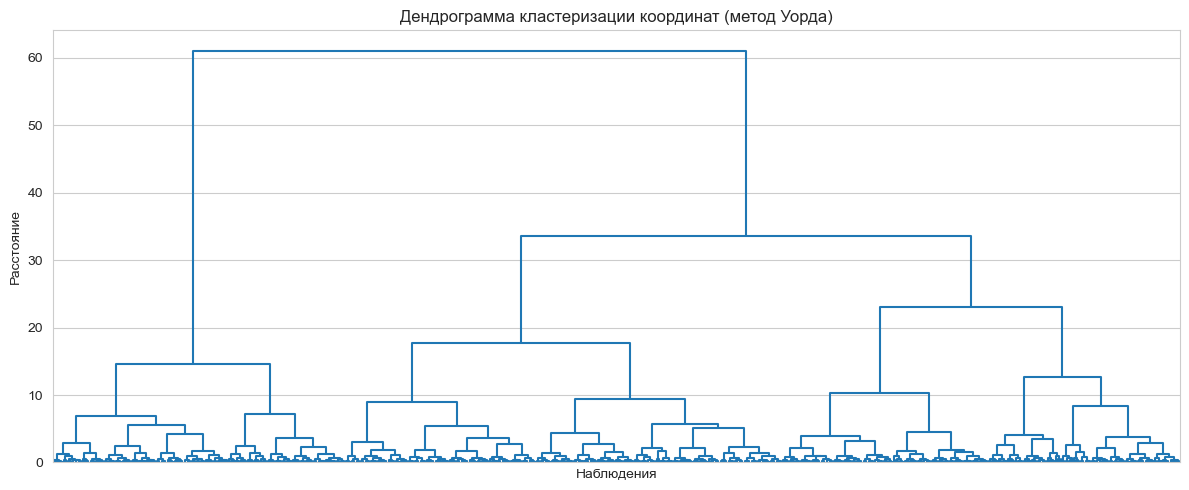

In [33]:
# ============================================================
# Кластерный анализ: шаг 2 — построение дендрограммы
# ============================================================

# 1. Матрица связей методом Уорда
linkage_matrix = linkage(coords_scaled, method='ward')
print("Матрица связей построена, форма:", linkage_matrix.shape)
print()

# 2. Дендрограмма
plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, no_labels=True, color_threshold=0)
plt.title('Дендрограмма кластеризации координат (метод Уорда)')
plt.xlabel('Наблюдения')
plt.ylabel('Расстояние')
plt.tight_layout()
plt.show()

### Выделение 5 кластеров

Пять кластеров выбраны по двум причинам. Первая — они соответствуют естественному географическому делению Северной Америки: западное побережье, запад Канады, центр, юго-восток и северо-восток. Вторая — порог 15 на дендрограмме даёт минимальное разбиение, при котором получается ровно пять групп; более низкие пороги дробят данные на 6–8 частей без пользы для анализа, более высокие — укрупняют до 4 и теряют одну зону.

In [34]:
# ============================================================
# Кластерный анализ: шаг 3 — выделение 5 кластеров
# ============================================================

# 1. Нарезать дерево на 5 кластеров
clusters = fcluster(linkage_matrix, t=15, criterion='distance')

# 2. Добавить метки в coords
coords = coords.copy()
coords['cluster'] = clusters

print("Распределение по кластерам:")
display(coords['cluster'].value_counts().sort_index())
print()

# 3. Присоединить метки обратно к df_data по координатам
df_data = df_data.merge(
    coords,
    on=['decimal_latitude', 'decimal_longitude'],
    how='left'
)

print("Размер df_data:", df_data.shape)
print("Пропусков в cluster:", df_data['cluster'].isna().sum())

Распределение по кластерам:


cluster
1    456
2    297
3    383
4    321
5    299
Name: count, dtype: int64


Размер df_data: (70973, 14)
Пропусков в cluster: 0


Дендрограмма нарезана на 5 кластеров при пороге 15. Все 1756 координатных ячеек распределились по кластерам примерно равномерно — от 297 до 456 ячеек, без перекосов. Пропусков в cluster нет, размер df_data не изменился — 70 973 строки, добавился один столбец. Данные готовы к описанию кластеров.

### Описание кластеров

In [35]:
# ============================================================
# Кластерный анализ: шаг 4 — описание кластеров
# ============================================================

summary = df_data.groupby('cluster', observed=True).agg(
    наблюдений=('observations', 'sum'),
    средняя_широта=('decimal_latitude', 'mean'),
    средняя_долгота=('decimal_longitude', 'mean'),
    средняя_температура=('avg_temp_c', 'mean'),
    средняя_плотность=('density_per', 'mean')
)

cell_counts = (
    df_data[
        ['cluster', 'decimal_latitude', 'decimal_longitude']
    ]
    .drop_duplicates()
    .groupby('cluster', observed=True)
    .size()
)

summary['ячеек'] = cell_counts

# Сохраняем прежний порядок и названия столбцов.
summary = summary[
    [
        'наблюдений',
        'ячеек',
        'средняя_широта',
        'средняя_долгота',
        'средняя_температура',
        'средняя_плотность'
    ]
].round(2)

display(summary)

,наблюдений,ячеек,средняя_широта,средняя_долгота,средняя_температура,средняя_плотность
cluster,,,,,,
1,36232,456,62.66,-145.35,8.80,0.750000
2,38323,297,34.05,-98.34,9.78,62.380001
3,988241,383,41.74,-82.22,6.13,117.209999
4,219123,321,45.50,-118.36,4.67,26.270000
5,7751,299,57.29,-93.75,13.12,5.070000


Кластеры различаются по географии и плотности. Кластер 3 (северо-восток США и восток Канады) — самый крупный: 988 тыс. наблюдений из 1.29 млн, плотность 117 чел/км². Кластер 4 (запад США и Канады) — 219 тыс. наблюдений. Кластеры 1 (Аляска и север Канады) и 5 (центр Канады) — северные и малонаселённые, данных мало. Кластер 2 (юг США) — 38 тыс. наблюдений. Основная масса данных приходится на густонаселённый северо-восток, а северные зоны представлены слабо — это надо учитывать при сравнении кластеров.

Число ячеек рассчитано по уникальным парам координат. Средние характеристики рассчитаны по агрегированным строкам и могут учитывать одну ячейку несколько раз.

### Имена кластеров

In [36]:
# ============================================================
# Кластерный анализ: шаг 5 — имена кластеров
# ============================================================

cluster_names = {
    1: 'Север (Аляска и север Канады)',
    2: 'Юг США',
    3: 'Северо-восток США и восток Канады',
    4: 'Запад США и Канады',
    5: 'Центр Канады'
}

df_data['cluster_name'] = df_data['cluster'].map(cluster_names)

print("Распределение по кластерам с именами:")
display(df_data.groupby('cluster_name', observed=True).agg(
    наблюдений=('observations', 'sum'),
    средняя_широта=('decimal_latitude', 'mean')
).round(2))

Распределение по кластерам с именами:


,наблюдений,средняя_широта
cluster_name,,
Запад США и Канады,219123,45.50
Север (Аляска и север Канады),36232,62.66
Северо-восток США и восток Канады,988241,41.74
Центр Канады,7751,57.29
Юг США,38323,34.05


### Визуализация наблюдений по кластерам и годам

In [37]:
# Кнопка Play
play_button = Button(description='▶',
                     layout=Layout(width='80px', height='80px'))

# CSS: большой синий треугольник без рамки
display(HTML("""
<style>
    .jupyter-button {
        border: none !important;
        box-shadow: none !important;
        background: transparent !important;
        color: #2a7ae2 !important;
        font-size: 55px !important;
        line-height: 1 !important;
        padding: 0 !important;
    }
    .jupyter-button:hover {
        background: transparent !important;
        color: #1a5ab2 !important;
    }
</style>
"""))

# Крупный дисплей года
year_display = HTML(value="<div style='font-size:34px; font-weight:bold; "
                          "text-align:center;'>Все годы</div>",
                    layout=Layout(width='110px'))

# Область графика
output = Output(layout=Layout(width='700px'))

playing = {'active': False}

def draw_all():
    year_display.value = ("<div style='font-size:34px; font-weight:bold; "
                          "text-align:center;'>Все годы</div>")
    with output:
        output.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 8))
        for name, group in df_data.groupby('cluster_name', observed=True):
            ax.scatter(group['decimal_longitude'], group['decimal_latitude'],
                       s=5 + group['observations'] / 5, alpha=0.7, label=name)
        ax.set_title('Наблюдения за лебедями, все годы (1980–2023)', fontsize=12)
        ax.set_xlabel('Долгота')
        ax.set_ylabel('Широта')
        ax.set_xlim(-170, -50)
        ax.set_ylim(24, 75)
        ax.legend(loc='lower left', fontsize=12)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        plt.show()
        plt.close(fig)

def draw_year(year):
    year_display.value = (f"<div style='font-size:34px; font-weight:bold; "
                          f"text-align:center;'>{year}</div>")
    subset = df_data[df_data['year'] == year]
    with output:
        output.clear_output(wait=True)
        if len(subset) == 0:
            print(f"За {year} год наблюдений нет")
            return
        fig, ax = plt.subplots(figsize=(10, 8))
        for name, group in subset.groupby('cluster_name', observed=True):
            ax.scatter(group['decimal_longitude'], group['decimal_latitude'],
                       s=5 + group['observations'] / 5, alpha=0.7, label=name)
        ax.set_title(f'Наблюдения за лебедями, {year} год', fontsize=12)
        ax.set_xlabel('Долгота')
        ax.set_ylabel('Широта')
        ax.set_xlim(-170, -50)
        ax.set_ylim(24, 75)
        ax.legend(loc='lower left', fontsize=12)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        plt.show()
        plt.close(fig)

def on_play(b):
    if playing['active']:
        return
    playing['active'] = True
    for year in range(1980, 2024):
        draw_year(year)
        time.sleep(0.01)
    playing['active'] = False
    draw_all()

play_button.on_click(on_play)

# Исходный вид — все годы
draw_all()

# Раскладка: график слева, контролы справа
controls = VBox([play_button, year_display],
                layout=Layout(width='110px', margin='0 0 0 10px',
                              align_items='center'))

display(HBox([output, controls]))

HTML(value='\n<style>\n    .jupyter-button {\n        border: none !important;\n        box-shadow: none !impo…

### Выводы по кластерному анализу

По координатам наблюдений выделено 5 географических зон: Север (Аляска и север Канады), Запад США и Канады, Центр Канады, Юг США, Северо-восток США и восток Канады. Порог 15 на дендрограмме дал минимальное разбиение ровно на 5 групп, более низкие пороги дробили данные без пользы. Кластеры получились сбалансированными по числу ячеек (297–456), но сильно неравными по числу наблюдений. Северо-восток США и восток Канады — 988 тыс. наблюдений из 1.29 млн (77%), самая густонаселённая зона. Центр Канады — всего 7.7 тыс. Северные зоны представлены слабо, что надо учитывать при сравнении. Кластеры различаются по широте (от 34.05° на Юге США до 62.66° на Севере) и по плотности населения (от 0.75 до 117 чел/км²).

### Сохранение

In [38]:
# 1. Сохранить в CSV
df_data.to_csv('data_seasonal_enriched.csv', index=False)
print("Файл сохранён: data_seasonal_enriched.csv")

Файл сохранён: data_seasonal_enriched.csv


## Статистический анализ

#### Вспомогательные функции

Обычная OLS предполагает, что все наблюдения независимы. В наших данных это не так: наблюдения внутри одной координатной ячейки похожи друг на друга (одинаковая широта, климат, условия). Если это игнорировать, стандартные ошибки занижаются, а p-value становятся слишком оптимистичными. Кластеризация по ячейке исправляет это — наблюдения внутри одной ячейки считаются «зависимой группой».

In [39]:
def fit_ols_by_cell(subset, predictors):
    """
    OLS по прежним агрегированным строкам.
    Стандартные ошибки кластеризованы по координатной ячейке.

    Исходный DataFrame не изменяется.
    """
    needed = [
        'decimal_latitude',
        'decimal_longitude',
        *predictors
    ]

    work = subset.dropna(subset=needed).copy()

    if work.empty:
        return None

    X = sm.add_constant(
        work[predictors].astype('float64'),
        has_constant='add'
    )

    y = work['decimal_latitude'].astype('float64')

    # Нельзя оценить модель при постоянном отклике
    # или линейно зависимых столбцах.
    if y.nunique() < 2:
        return None

    if len(work) <= X.shape[1]:
        return None

    if np.linalg.matrix_rank(X.to_numpy()) < X.shape[1]:
        return None

    cell_index = pd.MultiIndex.from_frame(
        work[['decimal_latitude', 'decimal_longitude']]
    )

    cell_codes, unique_cells = pd.factorize(cell_index)

    if len(unique_cells) < 2:
        return None

    return sm.OLS(y, X).fit(
        cov_type='cluster',
        cov_kwds={
            'groups': cell_codes,
            'use_correction': True,
            'df_correction': True
        },
        use_t=True
    )

latitude_trend считает тренд широты по годам для подвыборки, но с кластеризованными стандартными ошибками — в отличие от обычного linregress.
обычная OLS занижает стандартные ошибки, потому что наблюдения внутри одной ячейки зависимы. Кластеризация делает p-value честнее.

In [40]:
def latitude_trend(subset):
    """
    Возвращает тот же набор значений, который использован
    в проекте для linregress:
    slope, intercept, r_value, p_value, std_err.
    """
    model = fit_ols_by_cell(subset, ['year'])

    if model is None:
        return (np.nan,) * 5

    slope = model.params['year']
    intercept = model.params['const']

    r_value = (
        np.sign(slope)
        * np.sqrt(np.clip(model.rsquared, 0, 1))
    )

    return (
        slope,
        intercept,
        r_value,
        model.pvalues['year'],
        model.bse['year']
    )

### Линейная регрессия по кластерам

In [41]:
# ============================================================
# Линейная регрессия: тренд широты по годам для каждого кластера
# ============================================================

results = []

for name, group in df_data.groupby('cluster_name', observed=True):
    slope, intercept, r_value, p_value, std_err = latitude_trend(group)
    results.append({
        'Кластер': name,
        'Наклон (град/год)': round(slope, 4),
        'R²': round(r_value**2, 4),
        'p-value': round(p_value, 4),
        'Наблюдений': group['observations'].sum()
    })

results_df = pd.DataFrame(results).sort_values('Наклон (град/год)')
display(results_df)

,Кластер,Наклон (град/год),R²,p-value,Наблюдений
3,Центр Канады,-0.2534,0.1462,0.0000,7751
1,Север (Аляска и север Канады),-0.0570,0.0159,0.0000,36232
4,Юг США,-0.0269,0.0051,0.0563,38323
0,Запад США и Канады,0.0136,0.0013,0.3311,219123
2,Северо-восток США и восток Канады,0.0258,0.0088,0.0004,988241


#### Разбивка по сезонам

Мы решили добавить разбивку по сезонам, так как предполагаем, что лебеди по-разному смещаются зимой и летом: зимой они тяготеют к южным широтам, летом — к северным. Если анализировать все данные вместе, эти противоположные движения могут гасить друг друга, и общий тренд покажет «ничего не происходит», хотя внутри сезонов смещение есть.

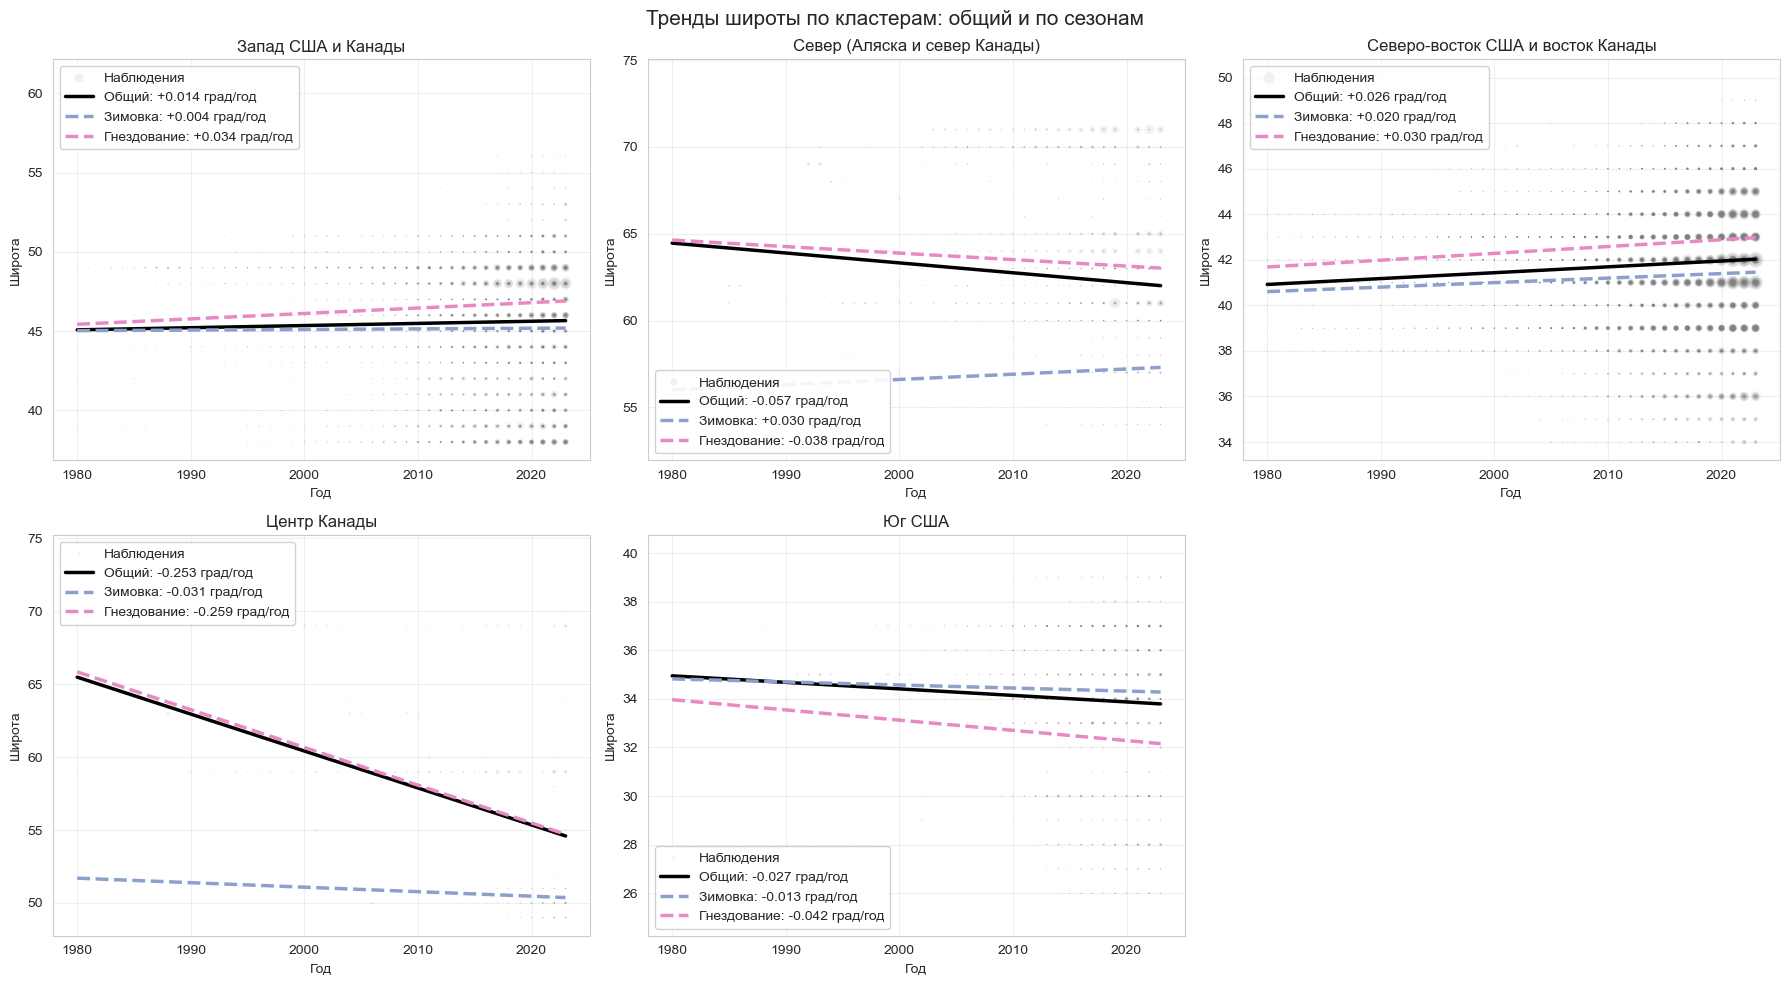

In [42]:
# ============================================================
# Визуализация: линейная регрессия по кластерам с сезонами
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

season_info = [
    (1, 'Зимовка', '#8da0cb'),
    (2, 'Гнездование', '#e78ac3')
]

for i, (name, group) in enumerate(df_data.groupby('cluster_name', observed=True)):
    ax = axes[i]

    # --- Общие точки наблюдений---
    ax.scatter(group['year'], group['decimal_latitude'],
               s=group['observations'] / 15,
               alpha=0.1,
               color='gray',
               edgecolor='none',
               label='Наблюдения')

    # --- Линия общего тренда (чёрная) ---
    slope_all, intercept_all, _, _, _ = latitude_trend(group)
    
    x_line = np.array([group['year'].min(), group['year'].max()])
    ax.plot(x_line, slope_all * x_line + intercept_all,
            color='black', linewidth=2.5,
            label=f'Общий: {slope_all:+.3f} град/год')

    # --- Линии трендов по сезонам ---
    for season, label, color in season_info:
        subset = group[group['period_type'] == season]
        if len(subset) < 10:
            continue
        slope_s, intercept_s, _, _, _ = latitude_trend(subset)
        
        ax.plot(x_line, slope_s * x_line + intercept_s,
                color=color, linewidth=2.5, linestyle='--',
                label=f'{label}: {slope_s:+.3f} град/год')

    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Год')
    ax.set_ylabel('Широта')
    ax.legend(fontsize=10, loc='best', framealpha=0.9)
    ax.grid(alpha=0.3)

axes[5].axis('off')
plt.suptitle('Тренды широты по кластерам: общий и по сезонам', fontsize=15)
plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# Таблица: тренды широты по кластерам и сезонам
# ============================================================

results = []

for name, group in df_data.groupby('cluster_name', observed=True):
    # Общий тренд
    slope_all, _, r_all, p_all, _ = latitude_trend(group)
    results.append({
        'Кластер': name,
        'Сезон': 'Общий',
        'Наклон, град/год': round(slope_all, 4),
        'R²': round(r_all**2, 4),
        'p-value': f'{p_all:.2e}',
        'Наблюдений': group['observations'].sum()
    })

    # По сезонам
    for season, label in [(1, 'Зимовка'), (2, 'Гнездование')]:
        subset = group[group['period_type'] == season]
        if len(subset) < 10:
            continue
        slope_s, _, r_s, p_s, _ = latitude_trend(subset)
        results.append({
            'Кластер': name,
            'Сезон': label,
            'Наклон, град/год': round(slope_s, 4),
            'R²': round(r_s**2, 4),
            'p-value': f'{p_s:.2e}',
            'Наблюдений': subset['observations'].sum()
        })

results_df = pd.DataFrame(results)
display(results_df)

,Кластер,Сезон,"Наклон, град/год",R²,p-value,Наблюдений
0,Запад США и Канады,Общий,0.0136,0.0013,3.31e-01,219123
1,Запад США и Канады,Зимовка,0.0038,0.0001,8.22e-01,189012
2,Запад США и Канады,Гнездование,0.0342,0.0065,1.89e-02,30111
3,Север (Аляска и север Канады),Общий,-0.0570,0.0159,1.32e-05,36232
4,Север (Аляска и север Канады),Зимовка,0.0302,0.0101,1.10e-01,2783
5,Север (Аляска и север Канады),Гнездование,-0.0375,0.0085,2.49e-03,33449
6,Северо-восток США и восток Канады,Общий,0.0258,0.0088,3.83e-04,988241
7,Северо-восток США и восток Канады,Зимовка,0.0198,0.0061,7.57e-03,683780
8,Северо-восток США и восток Канады,Гнездование,0.0300,0.0109,6.15e-04,304461
9,Центр Канады,Общий,-0.2534,0.1462,8.98e-09,7751


Тренды широты различаются по кластерам и сезонам.

На Северо-востоке ареал смещается на север стабильно: и зимой (+0.020), и летом (+0.030). Это самый надёжный результат — 988 тыс. наблюдений.

На Западе и на Севере зимние и летние тренды идут в разные стороны. На Западе летом ареал уходит на север (+0.034), зимой стоит на месте. На Севере зимой на север (+0.030), летом на юг (−0.038). Общий тренд маскирует это разнонаправленное движение.

В Центре Канады самый сильный тренд на юг (−0.25), но он создаётся гнездованием. Зимних данных мало (123 наблюдения) — вывод по зиме ненадёжен.

На Юге США тренд слабый на юг (−0.027), зимой почти ноль, летом чуть сильнее.

Главный вывод: анализировать общий тренд без разбивки по сезонам нельзя — в двух кластерах из пяти сезоны тянут ареал в противоположные стороны. Сезонность — ключевой фактор, который меняет интерпретацию смещения.

Разделение регрессии по кластерам и сезонам показало то, что общая модель скрывала. В двух кластерах из пяти — на Западе и на Севере — зимние и летние тренды идут в разные стороны: летом ареал смещается на север, зимой на юг или стоит на месте. Общий тренд по этим зонам близок к нулю, но это не отсутствие движения, а результат взаимного гашения противоположных сезонных сдвигов. Только на Северо-востоке тренд на север стабилен в оба сезона — и именно там больше всего данных. Вывод: анализировать смещение ареала без разбивки по сезонам нельзя — сезонность не просто добавляет нюанс, она меняет знак и интерпретацию тренда в половине зон.

In [44]:
# ============================================================
# Таблица: тренды широты по кластерам и видам, отдельно по сезонам
# ============================================================

from scipy.stats import linregress

species_list = ['Cygnus olor', 'Cygnus buccinator', 'Cygnus columbianus']
species_labels = {
    'Cygnus olor': 'Шипун',
    'Cygnus buccinator': 'Трубач',
    'Cygnus columbianus': 'Тундровый'
}

rows = []
for cluster in df_data['cluster_name'].unique():
    for sp in species_list:
        for season, season_label in [(1, 'Зимовка'), (2, 'Гнездование')]:
            subset = df_data[
                (df_data['cluster_name'] == cluster) &
                (df_data['species'] == sp) &
                (df_data['period_type'] == season)
            ]
            if len(subset) < 20:
                rows.append({
                    'Кластер': cluster,
                    'Вид': species_labels[sp],
                    'Сезон': season_label,
                    'Наклон, град/год': None,
                    'p-value': None,
                    'Наблюдений': int(subset['observations'].sum()),
                    'Значим': '—'
                })
                continue

            slope, _, _, p, _ = linregress(subset['year'],
                                            subset['decimal_latitude'])
            rows.append({
                'Кластер': cluster,
                'Вид': species_labels[sp],
                'Сезон': season_label,
                'Наклон, град/год': round(slope, 4),
                'p-value': f'{p:.2e}',
                'Наблюдений': subset['observations'].sum(),
                'Значим': 'да' if p < 0.05 else 'нет'
            })

trends_table = pd.DataFrame(rows)
display(trends_table)

,Кластер,Вид,Сезон,"Наклон, град/год",p-value,Наблюдений,Значим
0,Юг США,Шипун,Зимовка,-0.0385,7.86e-04,14235,да
1,Юг США,Шипун,Гнездование,-0.0409,1.70e-02,4476,да
2,Юг США,Трубач,Зимовка,0.0219,2.68e-02,6194,да
3,Юг США,Трубач,Гнездование,-0.1261,1.57e-01,245,нет
4,Юг США,Тундровый,Зимовка,0.0328,5.54e-14,13071,да
5,Юг США,Тундровый,Гнездование,NaN,None,102,—
6,Северо-восток США и восток Канады,Шипун,Зимовка,-0.0100,2.54e-06,377650,да
7,Северо-восток США и восток Канады,Шипун,Гнездование,-0.0048,5.39e-02,212002,нет
8,Северо-восток США и восток Канады,Трубач,Зимовка,0.0025,5.66e-01,124760,нет
9,Северо-восток США и восток Канады,Трубач,Гнездование,0.0044,3.21e-01,90391,нет


#### КУДА СМЕЩАЕТСЯ АРЕАЛ (тренды по кластерам, сезонам и видам)

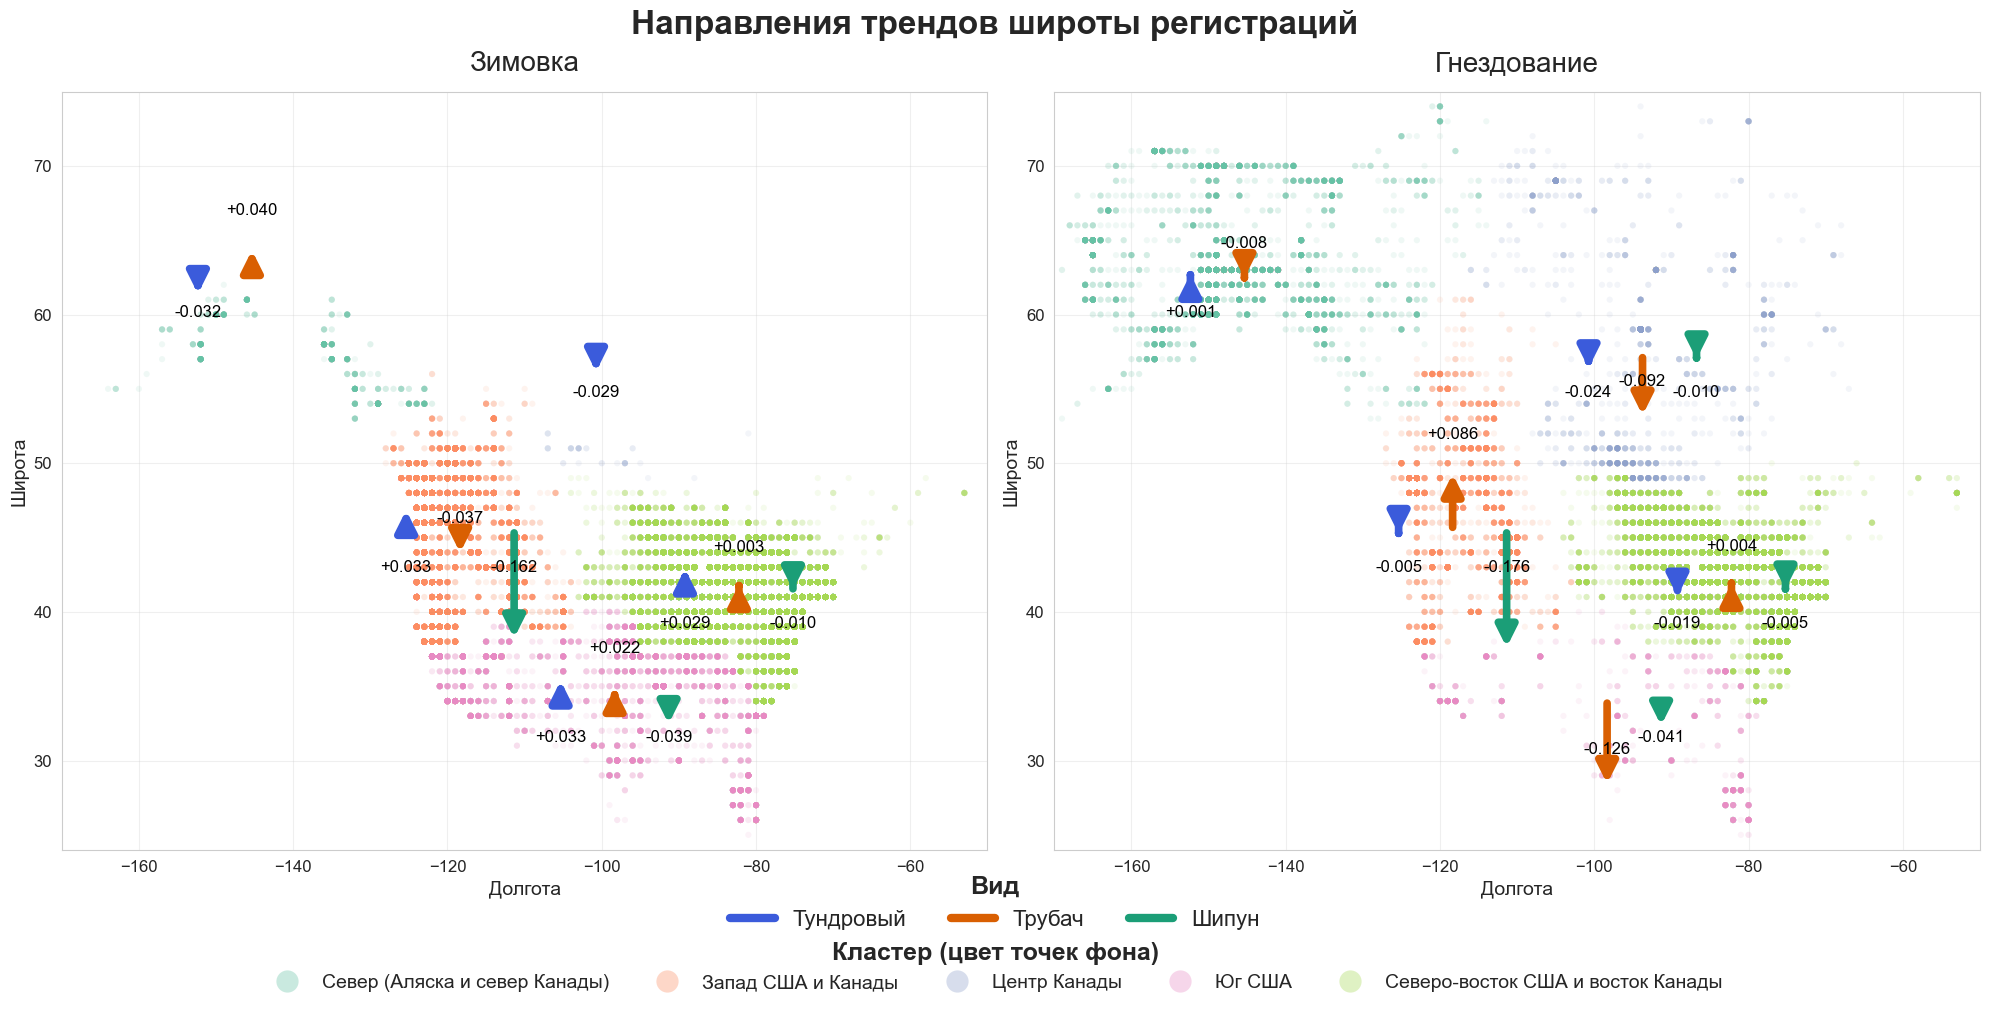

In [45]:
# ============================================================
# Визуализация: стрелки трендов широты по кластерам и видам
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

species_colors = {
    'Cygnus olor': '#1b9e77',
    'Cygnus buccinator': '#d95f02',
    'Cygnus columbianus': '#3b5bdb'
}

species_labels = {
    'Cygnus olor': 'Шипун',
    'Cygnus buccinator': 'Трубач',
    'Cygnus columbianus': 'Тундровый'
}

species_list = ['Cygnus columbianus', 'Cygnus buccinator', 'Cygnus olor']

cluster_colors = {
    'Север (Аляска и север Канады)': '#66c2a5',
    'Запад США и Канады': '#fc8d62',
    'Центр Канады': '#8da0cb',
    'Юг США': '#e78ac3',
    'Северо-восток США и восток Канады': '#a6d854'
}

centers = df_data.groupby('cluster_name', observed=True).agg(
    lat=('decimal_latitude', 'mean'),
    lon=('decimal_longitude', 'mean')
).reset_index()


def get_slope(cluster, sp, season):
    subset = df_data[
        (df_data['cluster_name'] == cluster)
        & (df_data['species'] == sp)
        & (df_data['period_type'] == season)
    ]

    if len(subset) < 20:
        return None, 'insufficient'

    slope, _, _, p, _ = latitude_trend(subset)

    if not np.isfinite(slope) or not np.isfinite(p):
        return None, 'insufficient'

    if p < 0.05:
        return slope, 'significant'

    return slope, 'uncertain'


fig, axes = plt.subplots(1, 2, figsize=(20, 10))

scale_factor = 46

for ax, (season, season_label) in zip(axes, [(1, 'Зимовка'), (2, 'Гнездование')]):

    # --- Фон: точки наблюдений по кластерам ---
    for cluster, color in cluster_colors.items():
        subset_c = df_data[
            (df_data['period_type'] == season) &
            (df_data['cluster_name'] == cluster)
        ]
        ax.scatter(subset_c['decimal_longitude'], subset_c['decimal_latitude'],
                   s=20, alpha=0.1, color=color, edgecolor='none')

    # --- Стрелки трендов ---
    for _, row in centers.iterrows():
        cluster = row['cluster_name']
        lat_c, lon_c = row['lat'], row['lon']

        offsets = [-7.0, 0, 7.0]
        label_positions = ['bottom', 'top', 'bottom']

        for i, sp in enumerate(species_list):
            slope, status = get_slope(cluster, sp, season)
            if status == 'insufficient':
                continue
            x_start = lon_c + offsets[i]
            y_start = lat_c

            # Нет данных или модель не построилась — кружок
            if status == 'insufficient':
                ax.scatter(x_start, y_start, s=180,
                           facecolor=species_colors[sp],
                           edgecolor='white', linewidth=1.5,
                           alpha=0.95, zorder=5)
                continue

            # Длина стрелки
            length = slope * scale_factor
            y_end = y_start + length

            # Цвет обводки наконечника: чёрный для значимых, серый для неуверенных
            edge_color = 'black' if status == 'significant' else 'lightgray'

            ax.annotate('',
                        xy=(x_start, y_end),
                        xytext=(x_start, y_start),
                        arrowprops=dict(arrowstyle='-|>',
                                        color=species_colors[sp],
                                        lw=5.5,
                                        alpha=1.0,
                                        mutation_scale=30))

            # Подпись значения тренда
            if label_positions[i] == 'bottom':
                ax.text(x_start, y_start - 2.0,
                        f'{slope:+.3f}',
                        fontsize=12, ha='center', va='top',
                        color='black', fontweight='normal')
            else:
                ax.text(x_start, y_end + 2.0,
                        f'{slope:+.3f}',
                        fontsize=12, ha='center', va='bottom',
                        color='black', fontweight='normal')

    ax.set_xlim(-170, -50)
    ax.set_ylim(24, 75)
    ax.set_title(f'{season_label}', fontsize=20, pad=15)
    ax.set_xlabel('Долгота', fontsize=14)
    ax.set_ylabel('Широта', fontsize=14)
    ax.tick_params(labelsize=12)
    ax.grid(alpha=0.3)

# --- Легенда видов ---
species_handles = [
    Line2D([0], [0], color=species_colors[sp], lw=6,
           label=species_labels[sp])
    for sp in species_list
]
legend1 = fig.legend(handles=species_handles,
                      loc='lower center', ncol=3, frameon=False,
                      bbox_to_anchor=(0.5, 0.04),
                      title='Вид',
                      prop={'size': 16, 'weight': 'normal'},
                      title_fontproperties={'size': 18, 'weight': 'bold'})

# --- Легенда кластеров ---
cluster_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color, markeredgecolor='none',
           markersize=16, alpha=0.35,
           label=cluster)
    for cluster, color in cluster_colors.items()
]
legend2 = fig.legend(handles=cluster_handles,
                      loc='lower center', ncol=5, frameon=False,
                      bbox_to_anchor=(0.5, -0.02),
                      title='Кластер (цвет точек фона)',
                      prop={'size': 14, 'weight': 'normal'},
                      title_fontproperties={'size': 18, 'weight': 'bold'})

plt.suptitle('Направления трендов широты регистраций', fontweight='bold', fontsize=24)
plt.tight_layout()
plt.subplots_adjust(bottom=0.14)
plt.show()


На графике и в таблице показаны тренды широты для каждого вида лебедей в каждой географической зоне отдельно для зимовки и гнездования.

**Что означают числа.** Наклон тренда в градусах широты за год. Положительный — ареал смещается на север (стрелка вверх), отрицательный — на юг (стрелка вниз). Чем больше модуль, тем быстрее смещение. Например, −0.162 у шипуна на Западе зимой означает движение на юг примерно на 6.5° за 40 лет.

**Что означают стрелки и кружки.** Стрелка рисуется, только если тренд статистически значим (p < 0.05). Кружок — значимого тренда нет, вид в этой зоне присутствует, но ареал не смещается.

**Что видно из таблицы.**

Большинство значимых трендов направлены на юг. Самые сильные — у шипуна на Западе (и зимой, и летом), у трубача в Центре Канады летом, у шипуна на Юге США.

На север смещается только тундровый лебедь на Юге и Северо-востоке зимой, трубач на Юге зимой, трубач на Западе летом, трубач на Севере зимой.

У шипуна и тундрового лебедя направления трендов часто противоположны в одной и той же зоне и сезоне. Это значит, что виды по-разному реагируют на одни и те же условия — их нельзя объединять в общий анализ.

Много ячеек с «нет» и «—» — там либо тренд незначим, либо данных слишком мало (меньше 20 наблюдений). Особенно это касается северных зон и зимних наблюдений шипуна: в Центре Канады и на Севере у шипуна почти нет зимних данных.

**Главный вывод.** Смещение ареала сильно различается по видам, зонам и сезонам. Единого тренда «лебеди двигаются на север» или «на юг» нет. В одних комбинациях вид уходит на север, в других — на юг, в третьих стоит на месте. Поэтому анализ по всей выборке без разбивки на виды и сезоны дал бы усреднённую и обманчивую картину.

### Корреляционный анализ

*Корреляции и ранговые тесты рассчитаны по агрегированным строкам. Поскольку одни координатные ячейки и региональные характеристики повторяются, стандартные p-value этих тестов не учитывают структуру зависимости данных. Поэтому блок используется для описания различий и связей в выборке, а не как самостоятельное доказательство изменения ареала.*

Посчитаем корреляцию:

широта vs температура — в целом и по сезонам;

широта vs плотность населения.

Корреляция показывает, связаны ли две переменные. Если широта растёт, а температура падает — это отрицательная связь. Если широта растёт и плотность растёт — положительная.

In [46]:
# ============================================================
# Корреляционный анализ
# ============================================================

# 1. Широта vs температура — в целом
r, p = pearsonr(df_data['decimal_latitude'], df_data['avg_temp_c'])
print(f"Широта vs температура (Пирсон): r = {r:.3f}, p = {p:.4f}")

rho, p = spearmanr(df_data['decimal_latitude'], df_data['avg_temp_c'])
print(f"Широта vs температура (Спирмен): ρ = {rho:.3f}, p = {p:.4f}")
print()

# 2. Широта vs температура по сезонам
for season, label in [(1, 'Зимовка'), (2, 'Гнездование')]:
    subset = df_data[df_data['period_type'] == season]
    r, p = pearsonr(subset['decimal_latitude'], subset['avg_temp_c'])
    print(f"{label}: r = {r:.3f}, p = {p:.4f}")
print()

# 3. Широта vs плотность населения
r, p = pearsonr(df_data['decimal_latitude'], df_data['density_per'])
print(f"Широта vs плотность (Пирсон): r = {r:.3f}, p = {p:.4f}")

rho, p = spearmanr(df_data['decimal_latitude'], df_data['density_per'])
print(f"Широта vs плотность (Спирмен): ρ = {rho:.3f}, p = {p:.4f}")

Широта vs температура (Пирсон): r = 0.014, p = 0.0002
Широта vs температура (Спирмен): ρ = -0.064, p = 0.0000

Зимовка: r = -0.592, p = 0.0000
Гнездование: r = -0.869, p = 0.0000

Широта vs плотность (Пирсон): r = -0.255, p = 0.0000
Широта vs плотность (Спирмен): ρ = -0.653, p = 0.0000


Широта и температура связаны сильно, но только внутри сезона. Зимой r = −0.59, летом r = −0.87: чем севернее, тем холоднее. В общей выборке эта связь исчезает (r = 0.01), потому что зима и лето гасят друг друга — смешивать сезоны нельзя.

Широта и плотность населения связаны умеренно отрицательно (Спирмен −0.65): чем севернее, тем меньше людей. Пирсон даёт всего −0.26, потому что на него влияет выброс — округ Колумбия с плотностью 4297 чел/км².

In [47]:
for name, group in df_data.groupby('cluster_name', observed=True):
    r, p = pearsonr(group['decimal_latitude'], group['avg_temp_c'])
    print(f"{name}: r = {r:.3f}, p = {p:.2e}")

Запад США и Канады: r = -0.076, p = 1.90e-22
Север (Аляска и север Канады): r = 0.387, p = 4.03e-196
Северо-восток США и восток Канады: r = 0.015, p = 2.27e-03
Центр Канады: r = -0.525, p = 7.18e-103
Юг США: r = -0.580, p = 0.00e+00


Корреляция широты и температуры сильно различается по кластерам. На Юге США и в Центре Канады связь умеренная отрицательная (r = −0.58 и −0.53): чем севернее, тем холоднее. На Западе и Северо-востоке связи почти нет (r = −0.08 и +0.02) — там климат зависит не столько от широты, сколько от близости к океану. А на Севере связь вообще положительная (r = +0.39): северные прибрежные районы теплее внутренних южных. Вывод: связь широты и температуры не универсальна, она зависит от зоны, и смешивать кластеры в один расчёт нельзя.

### Тепловая карта корреляций

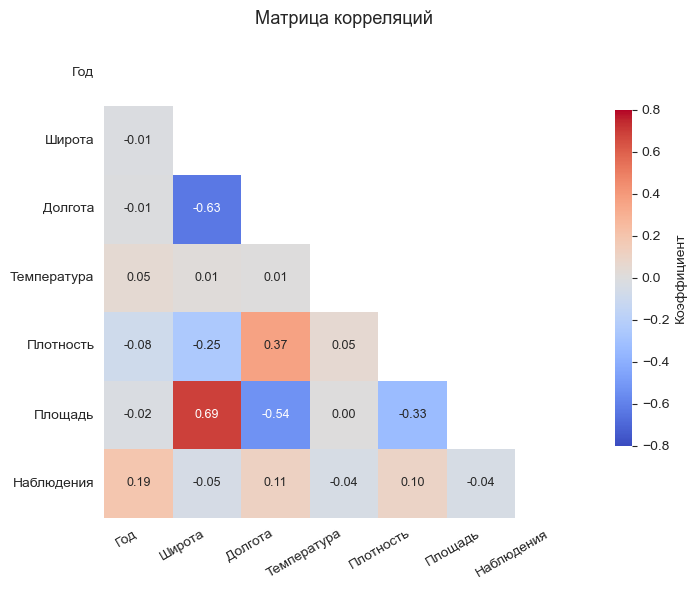

In [48]:
# ============================================================
# Визуализация: тепловая карта корреляций
# ============================================================

rename_map = {
    'year': 'Год',
    'decimal_latitude': 'Широта',
    'decimal_longitude': 'Долгота',
    'avg_temp_c': 'Температура',
    'density_per': 'Плотность',
    'land_area': 'Площадь',
    'observations': 'Наблюдения'
}

corr_cols = list(rename_map.keys())
corr_matrix = df_data[corr_cols].corr()
corr_matrix = corr_matrix.rename(index=rename_map, columns=rename_map)

# Маска: убираем верхний треугольник + диагональ
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)

plt.figure(figsize=(7.5, 6))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-0.8, vmax=0.8,
    square=True,
    linewidths=0,
    linecolor='white',
    cbar_kws={'shrink': 0.7, 'label': 'Коэффициент'},
    annot_kws={'fontsize': 9}
)

plt.title('Матрица корреляций', fontsize=13, pad=10)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Убрать сетку
plt.grid(False)

plt.tight_layout()
plt.show()

Матрица корреляций показывает: широта сильно связана с площадью (r = 0.69) и долготой (r = −0.63) — это география, а не биология. Широта и плотность связаны умеренно отрицательно (r = −0.26). Год и число наблюдений — слабо положительно (r = 0.19): чем позже, тем больше данных. Общий тренд широты по годам почти нулевой (r = −0.01), но по кластерам он разный — это подтверждает, что ареал смещается, просто в разных зонах по-разному.

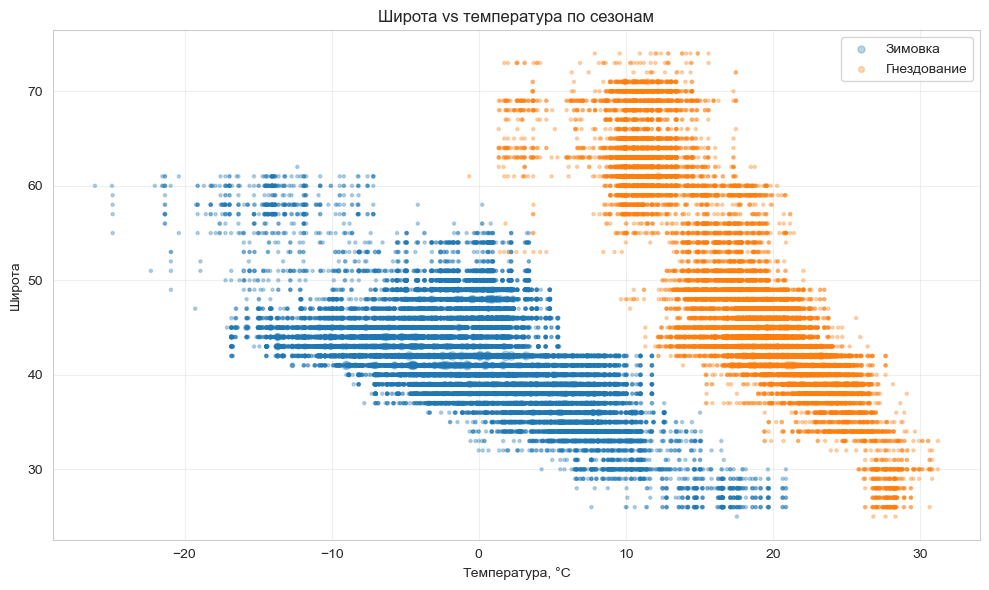

In [49]:
# ============================================================
# Визуализация 4: широта vs температура по сезонам
# ============================================================

plt.figure(figsize=(10, 6))

for season, label in [(1, 'Зимовка'), (2, 'Гнездование')]:
    subset = df_data[df_data['period_type'] == season]
    plt.scatter(subset['avg_temp_c'], subset['decimal_latitude'],
                s=5 + subset['observations'] / 50, alpha=0.3, label=label)

plt.title('Широта vs температура по сезонам')
plt.xlabel('Температура, °C')
plt.ylabel('Широта')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Зимнее и летнее облака на графике почти не пересекаются: зимой лебеди держатся южнее и в холоде, летом — севернее и в тепле. Внутри каждого сезона связь широты и температуры отрицательная, но между сезонами она разная. Из-за этого общая корреляция по всем данным близка к нулю — сезоны гасят друг друга. Вывод: связь широты и температуры нужно анализировать только с разбивкой по сезонам.

### Сравнение групп: Kruskal-Wallis

Kruskal-Wallis проверяет, различаются ли три и более групп по числовой переменной. Тест непараметрический, работает с рангами и не требует нормального распределения. Здесь три проверки: виды по широте, виды по температуре, сезоны по широте.

In [50]:
# ============================================================
# Сравнение групп: Kruskal-Wallis
# ============================================================

# 1. Виды по широте
groups = [df_data[df_data['species'] == sp]['decimal_latitude']
          for sp in df_data['species'].unique()]
stat, p = kruskal(*groups)
print(f"Виды по широте: H = {stat:.2f}, p = {p:.2e}")
print()

# 2. Виды по температуре
groups = [df_data[df_data['species'] == sp]['avg_temp_c']
          for sp in df_data['species'].unique()]
stat, p = kruskal(*groups)
print(f"Виды по температуре: H = {stat:.2f}, p = {p:.2e}")
print()

# 3. Сезоны по широте
winter = df_data[df_data['period_type'] == 1]['decimal_latitude']
summer = df_data[df_data['period_type'] == 2]['decimal_latitude']
stat, p = kruskal(winter, summer)
print(f"Сезоны по широте: H = {stat:.2f}, p = {p:.2e}")

Виды по широте: H = 10672.64, p = 0.00e+00

Виды по температуре: H = 3308.52, p = 0.00e+00

Сезоны по широте: H = 6961.25, p = 0.00e+00


Все три различия статистически значимы (p ≈ 0). Виды лебедей занимают разные широтные зоны и встречаются при разной температуре. Зимовка и гнездование сильно различаются по широте — это формальное подтверждение сезонного смещения ареала. Значения H большие, но при выборке в 70 тыс. строк даже малые различия становятся значимыми, поэтому смотреть надо и на сами средние по группам.

### Попарные сравнения видов: Mann-Whitney U

Kruskal-Wallis показал, что три вида лебедей значимо различаются по широте, температуре и плотности. Но он не говорит, между кем именно различия. Поэтому мы применяем Mann-Whitney U — непараметрический тест для попарного сравнения двух групп. Он не требует нормального распределения и работает с рангами, что подходит для наших скошенных данных. Попарно сравниваем все три пары видов по трём переменным — итого 9 сравнений. Если p < 0.05, различия между парой статистически значимы.

In [51]:
# ============================================================
# Попарные сравнения видов: Mann-Whitney U
# ============================================================

species_list = ['Cygnus olor', 'Cygnus buccinator', 'Cygnus columbianus']
species_labels = {
    'Cygnus olor': 'Шипун',
    'Cygnus buccinator': 'Трубач',
    'Cygnus columbianus': 'Тундровый'
}

# Сравниваем по трём переменным
variables = [
    ('decimal_latitude', 'Широта'),
    ('avg_temp_c', 'Температура'),
    ('density_per', 'Плотность')
]

rows = []

for var, var_label in variables:
    for sp1, sp2 in combinations(species_list, 2):
        g1 = df_data[df_data['species'] == sp1][var]
        g2 = df_data[df_data['species'] == sp2][var]

        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')

        rows.append({
            'Переменная': var_label,
            'Пара видов': f'{species_labels[sp1]} — {species_labels[sp2]}',
            'Медиана 1': round(g1.median(), 2),
            'Медиана 2': round(g2.median(), 2),
            'U': int(stat),
            'p-value': f'{p:.2e}',
            'Значимо': 'да' if p < 0.05 else 'нет'
        })

mw_table = pd.DataFrame(rows)
display(mw_table)

,Переменная,Пара видов,Медиана 1,Медиана 2,U,p-value,Значимо
0,Широта,Шипун — Трубач,41.00,45.00,134532458,0.00e+00,да
1,Широта,Шипун — Тундровый,41.00,42.00,214246055,1.83e-267,да
2,Широта,Трубач — Тундровый,45.00,42.00,336603238,0.00e+00,да
3,Температура,Шипун — Трубач,7.67,4.22,357000043,2.76e-202,да
4,Температура,Шипун — Тундровый,7.67,1.72,340984483,0.00e+00,да
5,Температура,Трубач — Тундровый,4.22,1.72,314436629,4.41e-261,да
6,Плотность,Шипун — Трубач,86.00,17.00,504387813,0.00e+00,да
7,Плотность,Шипун — Тундровый,86.00,45.00,356930742,0.00e+00,да
8,Плотность,Трубач — Тундровый,17.00,45.00,198537688,0.00e+00,да


Все три вида значимо различаются по всем трём переменным — ни одна пара не оказалась похожей.

**Широта:** трубач севернее (медиана 45°), тундровый посередине (42°), шипун южнее (41°).

**Температура:** шипун в самых тёплых условиях (7.67 °C), трубач в умеренных (4.22 °C), тундровый в самых холодных (1.72 °C).

**Плотность:** шипун тяготеет к густонаселённым регионам (86 чел/км²), тундровый — к средним (45), трубач — к малонаселённым (17).

Вывод: виды занимают разные экологические ниши, их нельзя объединять в одну группу. Это подтверждает рост R² с 0.067 до 0.589 при добавлении вида в множественную регрессию.

### Визуализации

#### Широта и температура лебедей зимой и летом

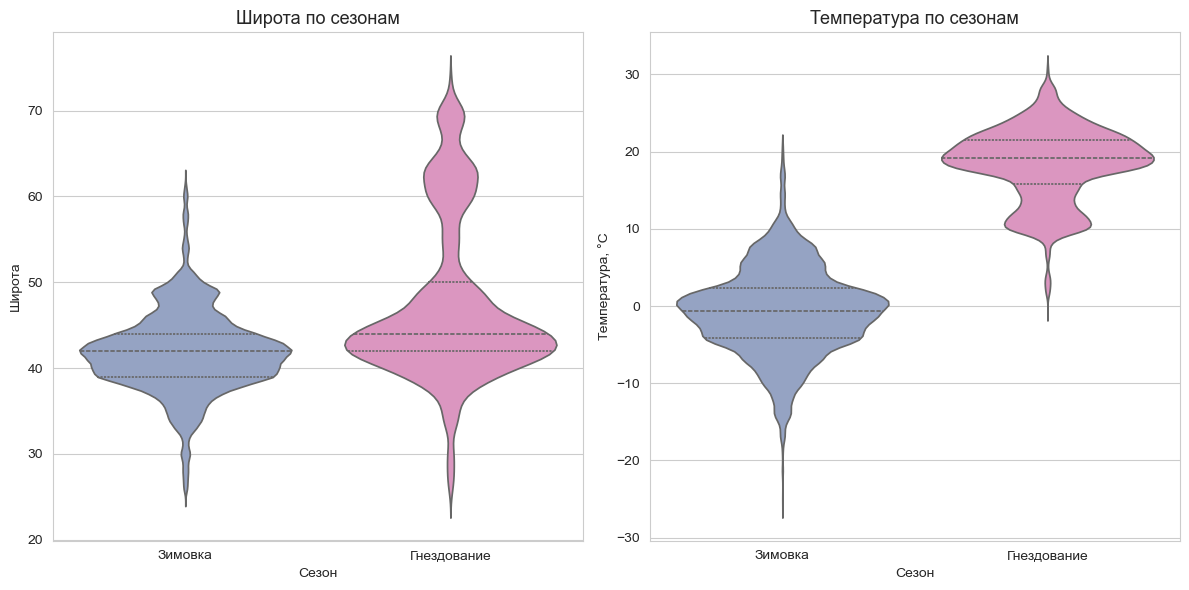

,Среднее_широта,Медиана_широта,Стд_широта,Среднее_темп,Медиана_темп,Стд_темп
season_ru,,,,,,
Гнездование,47.42,44.0,9.34,18.360001,19.110001,4.70
Зимовка,41.84,42.0,4.65,-0.700000,-0.610000,5.54


In [52]:
# ============================================================
# Визуализация: violin plot широты и температуры по сезонам
# ============================================================

season_labels = {1: 'Зимовка', 2: 'Гнездование'}
df_plot = df_data.copy()
df_plot['season_ru'] = df_plot['period_type'].map(season_labels)

season_colors = {
    'Зимовка': '#8da0cb',
    'Гнездование': '#e78ac3'
}

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Широта по сезонам ---
sns.violinplot(data=df_plot, x='season_ru', y='decimal_latitude',
               hue='season_ru', palette=season_colors, inner='quartile',
               legend=False, ax=axes[0])
axes[0].set_title('Широта по сезонам', fontsize=13)
axes[0].set_xlabel('Сезон')
axes[0].set_ylabel('Широта')

# --- Температура по сезонам ---
sns.violinplot(data=df_plot, x='season_ru', y='avg_temp_c',
               hue='season_ru', palette=season_colors, inner='quartile',
               legend=False, ax=axes[1])
axes[1].set_title('Температура по сезонам', fontsize=13)
axes[1].set_xlabel('Сезон')
axes[1].set_ylabel('Температура, °C')

plt.tight_layout()
plt.show()

# --- Сводка статистических характеристик ---
summary = df_plot.groupby('season_ru').agg(
    Среднее_широта=('decimal_latitude', 'mean'),
    Медиана_широта=('decimal_latitude', 'median'),
    Стд_широта=('decimal_latitude', 'std'),
    Среднее_темп=('avg_temp_c', 'mean'),
    Медиана_темп=('avg_temp_c', 'median'),
    Стд_темп=('avg_temp_c', 'std')
).round(2)

display(summary)

Зимой лебеди держатся южнее и в более холодных условиях, летом — севернее и при более высоких температурах. Средняя широта зимовки — 41.84°, гнездования — 47.42°. Средняя температура зимой — −0.70 °C, летом — +18.36 °C.

Разница по широте почти 6 градусов, по температуре — около 19 градусов. Летнее распределение широты шире: лебеди разлетаются от средних широт до самых северных. Зимой распределение более сконцентрированное — птицы держатся в умеренной зоне.

Это визуальное подтверждение сезонного смещения ареала, которое Kruskal-Wallis уже подтвердил статистически (H = 6961, p ≈ 0).

Тест показал, что виды различаются по широте и температуре. Violin plot ниже визуально показывает это различие.

#### Широта и температура по видам лебедей

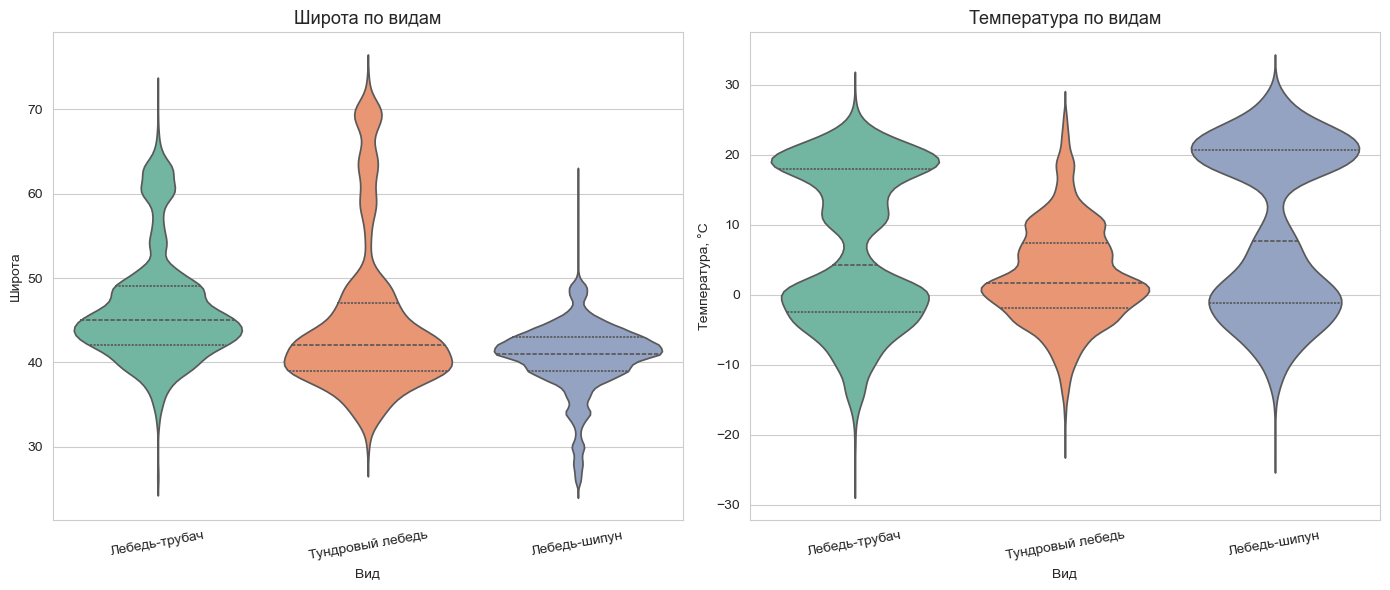

In [53]:
# ============================================================
# Визуализация violin plot широты и температуры по видам
# ============================================================

species_labels = {
    'Cygnus olor': 'Лебедь-шипун',
    'Cygnus buccinator': 'Лебедь-трубач',
    'Cygnus columbianus': 'Тундровый лебедь'
}

df_plot = df_data.copy()
df_plot['species_ru'] = df_plot['species'].map(species_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Широта по видам
sns.violinplot(data=df_plot, x='species_ru', y='decimal_latitude',
               hue='species_ru', palette='Set2', inner='quartile',
               legend=False, ax=axes[0])
axes[0].set_title('Широта по видам', fontsize=13)
axes[0].set_xlabel('Вид')
axes[0].set_ylabel('Широта')
axes[0].tick_params(axis='x', rotation=10)

# Температура по видам
sns.violinplot(data=df_plot, x='species_ru', y='avg_temp_c',
               hue='species_ru', palette='Set2', inner='quartile',
               legend=False, ax=axes[1])
axes[1].set_title('Температура по видам', fontsize=13)
axes[1].set_xlabel('Вид')
axes[1].set_ylabel('Температура, °C')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

Три вида лебедей занимают разные широтные зоны, различия значимы (Kruskal-Wallis, p ≈ 0).

- **Cygnus columbianus** — самый северный, тяготеет к тундре, встречается при низких температурах.
- **Cygnus buccinator** — промежуточный, средние широты, запад Северной Америки.
- **Cygnus olor** — самый южный, интродуцированный, держится в густонаселённых районах восточного побережья США при более высоких температурах.

Вывод: виды нельзя смешивать в одну группу — у каждого своя ниша. Именно поэтому добавление вида в регрессию подняло R² с 0.07 до 0.59 (далее в анализе множественной регрессией)

#### Наблюдения за лебедями по видам (интерактивная карта)

In [54]:
# Кнопка Play
play_button = Button(description='▶',
                     layout=Layout(width='80px', height='80px'))

display(HTML("""
<style>
    .jupyter-button {
        border: none !important;
        box-shadow: none !important;
        background: transparent !important;
        color: #2a7ae2 !important;
        font-size: 55px !important;
        line-height: 1 !important;
        padding: 0 !important;
    }
    .jupyter-button:hover {
        background: transparent !important;
        color: #1a5ab2 !important;
    }
</style>
"""))

year_display = HTML(value="<div style='font-size:34px; font-weight:bold; "
                          "text-align:center;'>Все годы</div>",
                    layout=Layout(width='110px'))

output = Output(layout=Layout(width='700px'))

playing = {'active': False}

# Цвета
species_colors = {
    'Cygnus olor': '#66c2a5',           # зелёный
    'Cygnus buccinator': '#fc8d62',      # оранжевый
    'Cygnus columbianus': '#8da0cb'      # синий
}

species_labels = {
    'Cygnus olor': 'Лебедь-шипун',
    'Cygnus buccinator': 'Лебедь-трубач',
    'Cygnus columbianus': 'Тундровый лебедь'
}

def draw_all():
    year_display.value = ("<div style='font-size:34px; font-weight:bold; "
                          "text-align:center;'>Все годы</div>")
    with output:
        output.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 7))
        for sp, color in species_colors.items():
            subset = df_data[df_data['species'] == sp]
            ax.scatter(subset['decimal_longitude'], subset['decimal_latitude'],
                       s=5 + subset['observations'] / 5,
                       alpha=0.9, color=color, label=species_labels[sp])
        ax.set_title('Наблюдения за лебедями по видам, все годы (1980–2023)',
                     fontsize=12)
        ax.set_xlabel('Долгота')
        ax.set_ylabel('Широта')
        ax.set_xlim(-170, -50)
        ax.set_ylim(24, 75)
        ax.legend(loc='lower left', fontsize=12)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        plt.show()
        plt.close(fig)

def draw_year(year):
    year_display.value = (f"<div style='font-size:34px; font-weight:bold; "
                          f"text-align:center;'>{year}</div>")
    with output:
        output.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 7))
        for sp, color in species_colors.items():
            subset = df_data[(df_data['species'] == sp) &
                             (df_data['year'] == year)]
            if len(subset) == 0:
                continue
            ax.scatter(subset['decimal_longitude'], subset['decimal_latitude'],
                       s=5 + subset['observations'] / 5,
                       alpha=0.9, color=color, label=species_labels[sp])
        ax.set_title(f'Наблюдения за лебедями по видам, {year} год',
                     fontsize=12)
        ax.set_xlabel('Долгота')
        ax.set_ylabel('Широта')
        ax.set_xlim(-170, -50)
        ax.set_ylim(24, 75)
        ax.legend(loc='lower left', fontsize=12)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        plt.show()
        plt.close(fig)

def on_play(b):
    if playing['active']:
        return
    playing['active'] = True
    for year in range(1980, 2024):
        draw_year(year)
        time.sleep(0.01)
    playing['active'] = False
    draw_all()

play_button.on_click(on_play)

draw_all()

controls = VBox([play_button, year_display],
                layout=Layout(width='110px', margin='0 0 0 10px',
                              align_items='center'))

display(HBox([output, controls]))

HTML(value='\n<style>\n    .jupyter-button {\n        border: none !important;\n        box-shadow: none !impo…

### Выводы по статистическому анализу

Линейная регрессия по кластерам показала слабые, но разнонаправленные тренды. На северо-востоке США и западе Канады широта медленно растёт (+0.026 и +0.014 град/год), на Юге США и в северных зонах — падает. Самый заметный отрицательный тренд в Центре Канады (−0.25 град/год), но там мало данных. Общий тренд по всей выборке почти нулевой — разнонаправленные сдвиги гасят друг друга.

Корреляционный анализ показал, что связь широты и температуры сильная только внутри сезона: зимой r = −0.59, летом r = −0.87. В общей выборке она исчезает, потому что зима и лето гасят друг друга. По кластерам связь тоже разная: на Юге и в Центре Канады она умеренная отрицательная, на Западе и Северо-востоке её нет, на Севере — положительная. Связь широты и плотности умеренная отрицательная (Спирмен −0.65): чем севернее, тем меньше людей.

Kruskal-Wallis подтвердил три различия: виды лебедей занимают разные широтные зоны (H = 10672), встречаются при разной температуре (H = 3308), зимовка и гнездование сильно различаются по широте (H = 6961). Все p-value ≈ 0. Сезонное смещение ареала подтверждено формально.

Корреляционный анализ показал, что широта и плотность связаны (−0.26). Множественная регрессия показала, что плотность — значимый предиктор. Но оба результата можно интерпретировать неверно: «лебеди избегают людей». На самом деле причина в том, что в густонаселённых районах больше наблюдателей, а значит, больше записей. Этот блок как раз объясняет, что связь плотности и наблюдений — это артефакт активности людей, а не биология птиц.

## Множественная регрессия

Линейная регрессия по одному году отвечает на вопрос «есть ли тренд». Множественная — на вопрос «какой фактор важнее и как они влияют вместе». Здесь мы одновременно учитываем год, температуру и плотность населения, чтобы понять, что из них связано с широтой сильнее.

In [55]:
# ============================================================
# Множественная регрессия
# ============================================================

import statsmodels.api as sm

# 1. Подготовить данные
model = fit_ols_by_cell(
    df_data,
    ['year', 'avg_temp_c', 'density_per']
)

if model is not None:
    print(model.summary())
else:
    print("Модель не может быть оценена.")

                            OLS Regression Results                            
Dep. Variable:       decimal_latitude   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     1.835
Date:                Fri, 25 Sep 2026   Prob (F-statistic):              0.139
Time:                        09:01:36   Log-Likelihood:            -2.3951e+05
No. Observations:               70973   AIC:                         4.790e+05
Df Residuals:                   70969   BIC:                         4.791e+05
Df Model:                           3                                         
Covariance Type:              cluster                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         100.1522     26.773      3.741      

Общая модель даёт R² = 0.067 и формально значимые, но крошечные коэффициенты. Причина — усреднение по несопоставимым группам: разнонаправленные тренды видов, сезонов и регионов гасят друг друга. Знак температуры даже получается неверным (+0.02), потому что зима и лето смешаны.

Разрезы решают эту проблему. В них R² доходит до 0.65–0.97, знаки коэффициентов становятся осмысленными, и видно, где каждый фактор реально работает. Общая модель говорит «факторы влияют», разрезы — «где, у кого и в какую сторону».

#### По кластерам, видам и сезонам

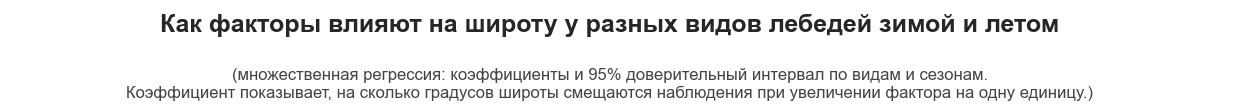

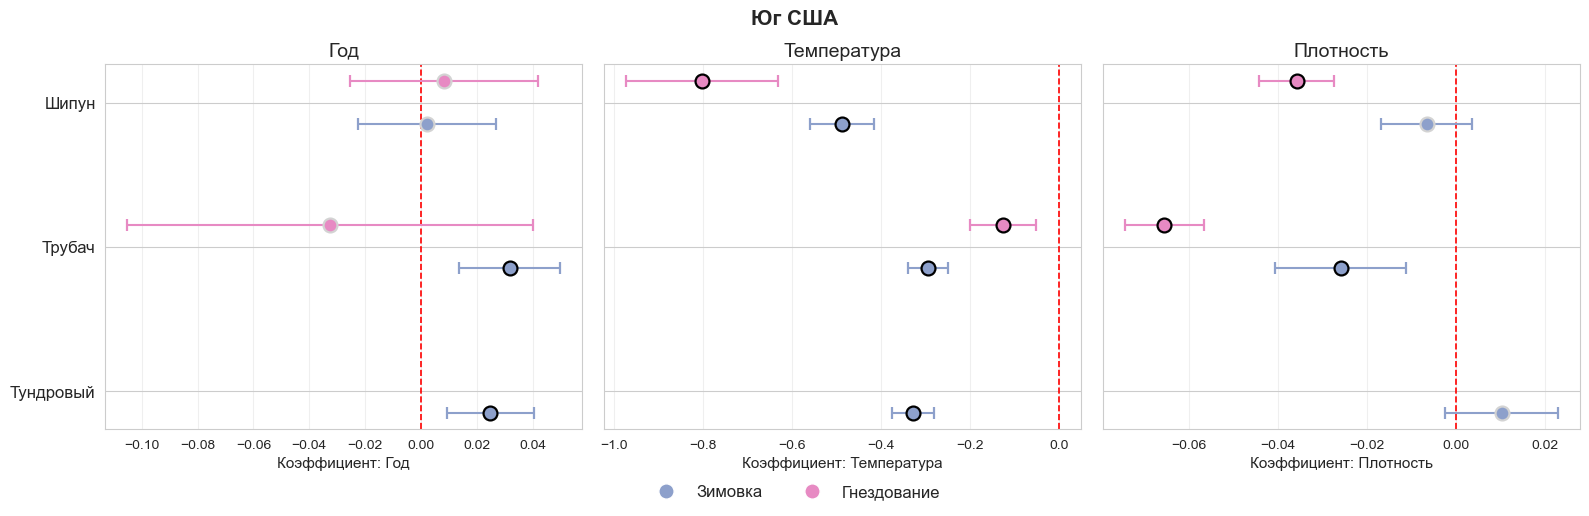

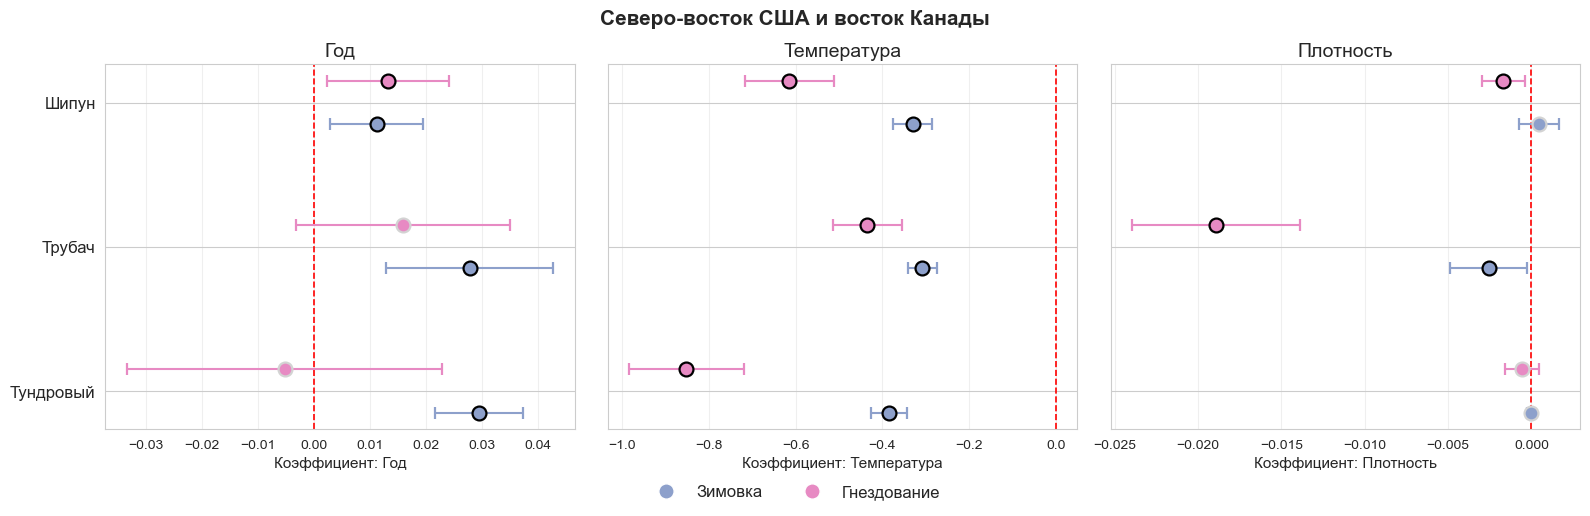

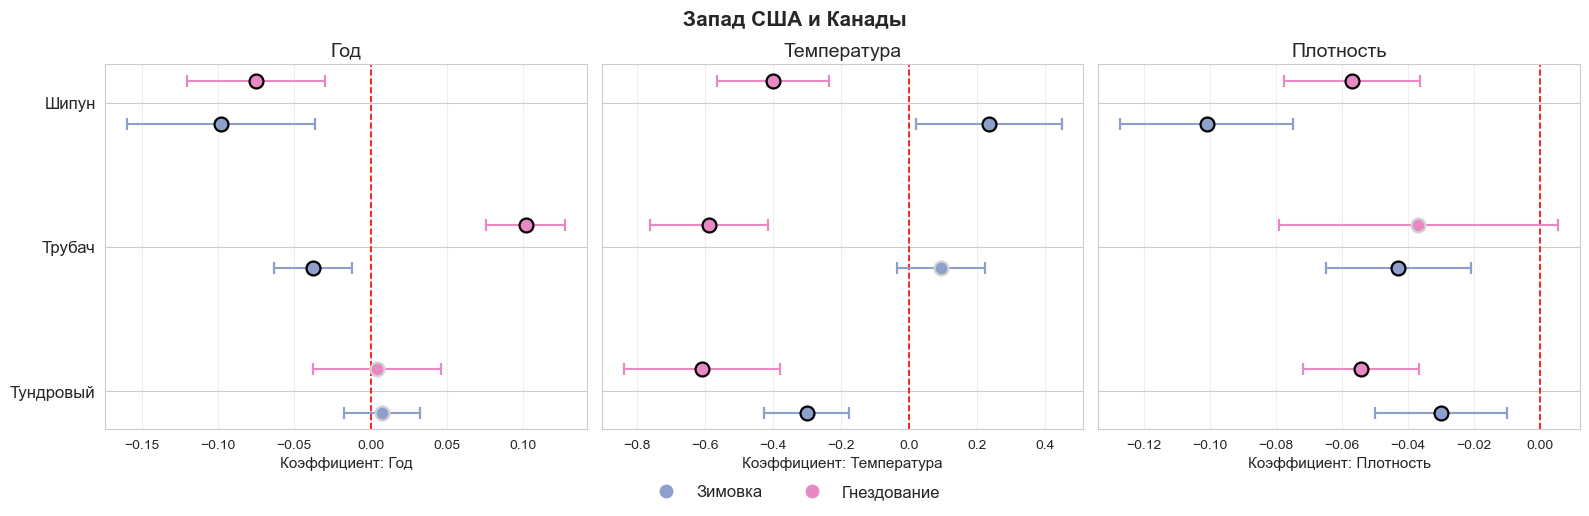

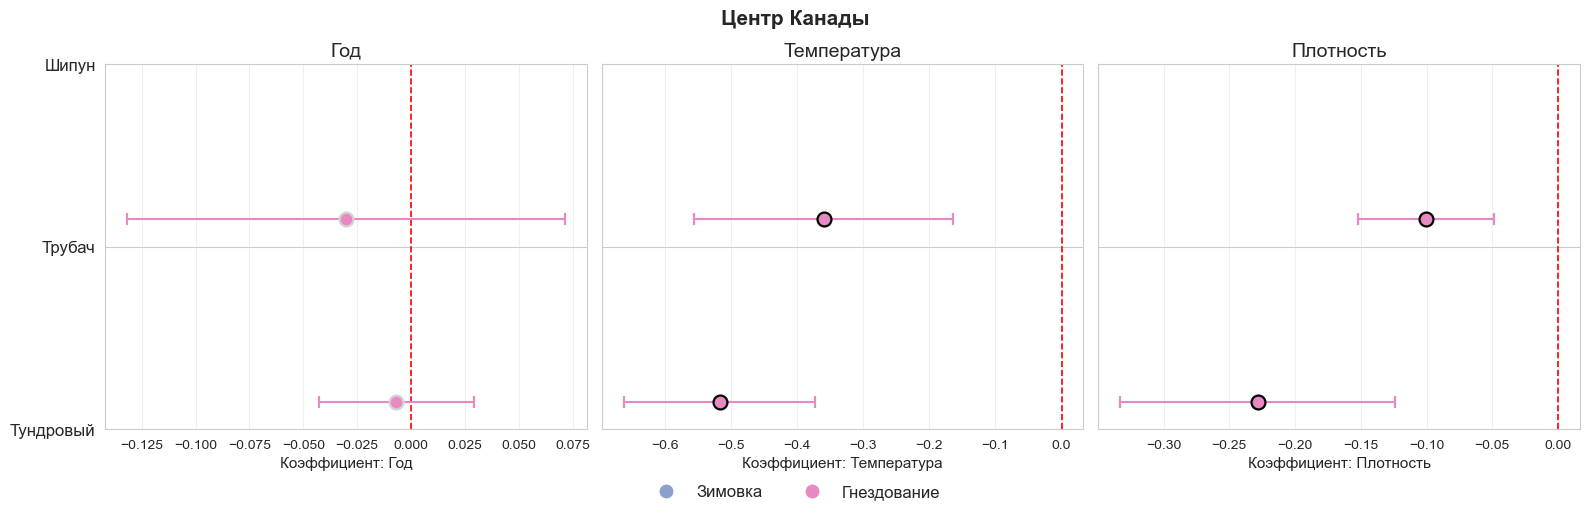

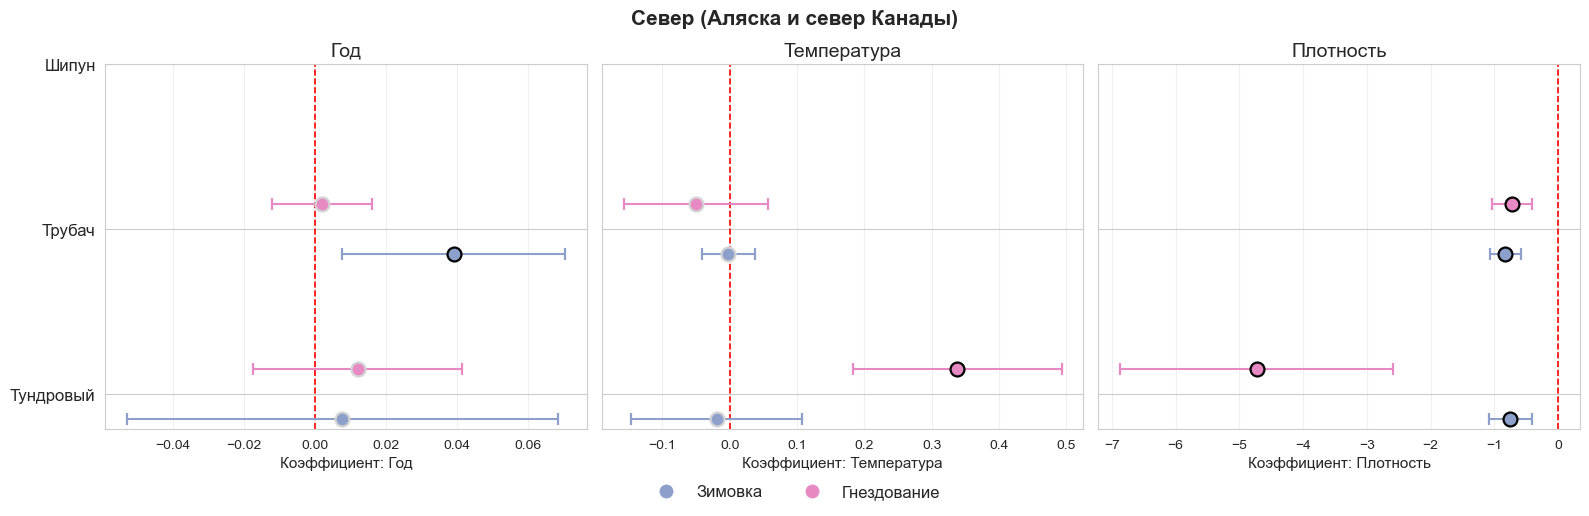

In [56]:
# ============================================================
# Множественная регрессия по кластерам: коэффициенты с 95% ДИ
# ============================================================

import statsmodels.api as sm
from matplotlib.lines import Line2D

species_labels = {
    'Cygnus columbianus': 'Тундровый',
    'Cygnus buccinator': 'Трубач',
    'Cygnus olor': 'Шипун'
}

species_list = ['Cygnus columbianus', 'Cygnus buccinator', 'Cygnus olor']

season_info = [
    (1, 'Зимовка', '#8da0cb'),
    (2, 'Гнездование', '#e78ac3')
]

def fit_model(subset):
    if len(subset) < 50:
        return None

    model = fit_ols_by_cell(
        subset,
        ['year', 'avg_temp_c', 'density_per']
    )

    if model is None:
        return None

    out = {}
    for factor in ['year', 'avg_temp_c', 'density_per']:
        out[factor] = {
            'coef': model.params[factor],
            'ci_low': model.conf_int().loc[factor, 0],
            'ci_high': model.conf_int().loc[factor, 1],
            'p': model.pvalues[factor]
        }
    return out

factors = [
    ('year', 'Год'),
    ('avg_temp_c', 'Температура'),
    ('density_per', 'Плотность')
]

clusters = df_data['cluster_name'].unique()

# ============================================================
# ОБЩИЙ ЗАГОЛОВОК
# ============================================================
fig_title = plt.figure(figsize=(16, 1.2))
fig_title.suptitle('Как факторы влияют на широту у разных видов лебедей зимой и летом',
                   fontsize=18, fontweight='bold', y=0.85)
fig_title.text(0.5, 0.15,
               '(множественная регрессия: коэффициенты и 95% доверительный интервал '
               'по видам и сезонам.\n'
               'Коэффициент показывает, на сколько градусов широты смещаются '
               'наблюдения при увеличении фактора на одну единицу.)',
               ha='center', fontsize=12, color='#444444')
fig_title.patch.set_alpha(0)
plt.axis('off')
plt.show()
# ============================================================
# Графики по кластерам (по одному на кластер)
# ============================================================
for cluster in clusters:
    cluster_data = df_data[df_data['cluster_name'] == cluster]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

    y_base = {sp: i for i, sp in enumerate(species_list)}
    offset = 0.15
    has_any_data = False

    for ax, (factor, factor_label) in zip(axes, factors):
        for sp in species_list:
            for season, season_label, color in season_info:
                subset = cluster_data[
                    (cluster_data['species'] == sp) &
                    (cluster_data['period_type'] == season)
                ]
                res = fit_model(subset)
                if res is None:
                    continue

                has_any_data = True
                coef = res[factor]['coef']
                ci_low = res[factor]['ci_low']
                ci_high = res[factor]['ci_high']
                p = res[factor]['p']

                y_pos = y_base[sp]
                y_shift = -offset if season == 1 else +offset
                err_low = coef - ci_low
                err_high = ci_high - coef

                ax.errorbar(coef, y_pos + y_shift,
                            xerr=[[err_low], [err_high]],
                            fmt='o', capsize=4,
                            ecolor=color,
                            markeredgecolor='black' if p < 0.05 else 'lightgray',
                            markeredgewidth=1.6,
                            markersize=10,
                            color=color,
                            elinewidth=1.5,
                            zorder=5)

        ax.axvline(0, color='red', linestyle='--', linewidth=1.2)
        ax.set_yticks(list(y_base.values()))
        ax.set_yticklabels([species_labels[sp] for sp in species_list],
                            fontsize=12)
        ax.set_xlabel(f'Коэффициент: {factor_label}', fontsize=11)
        ax.set_title(f'{factor_label}', fontsize=14)
        ax.tick_params(axis='x', labelsize=10)
        ax.grid(alpha=0.3, axis='x')

    if not has_any_data:
        plt.close(fig)
        continue

    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=color, markersize=11, label=label)
        for _, label, color in season_info
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2,
               fontsize=12, frameon=False, bbox_to_anchor=(0.5, -0.02))

    # Только название кластера — заголовок карточки
    fig.suptitle(cluster, fontsize=15, fontweight='bold', y=0.99)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, top=0.88)
    plt.show()

#### Покрытие данных по группам

Это карта доверия к данным. Объясняет, почему в одних группах коэффициенты устойчивы, а в других — пусто или широкий разброс. Без неё не понятно, где выводы надёжны, а где данных просто нет.

In [57]:
coverage = (
    df_data
    .groupby(
        ['cluster_name', 'species', 'period_type'],
        observed=True
    )
    .agg(
        n_rows=('year', 'size'),
        n_records=('observations', 'sum'),
        n_years=('year', 'nunique'),
        year_min=('year', 'min'),
        year_max=('year', 'max')
    )
)

cell_coverage = (
    df_data[
        [
            'cluster_name', 'species', 'period_type',
            'decimal_latitude', 'decimal_longitude'
        ]
    ]
    .drop_duplicates()
    .groupby(
        ['cluster_name', 'species', 'period_type'],
        observed=True
    )
    .size()
)

coverage['n_cells'] = cell_coverage

display(coverage)

n_rows  n_records  n_years  year_min  year_max  n_cells
cluster_name                      species            period_type                                                         
Запад США и Канады                Cygnus buccinator  1              5059      94935       44      1980      2023      213
                                                     2              3031      19327       44      1980      2023      223
                                  Cygnus columbianus 1              5921      76138       44      1980      2023      208
                                                     2               354       1419       43      1980      2023      116
                                  Cygnus olor        1              1119      17939       44      1980      2023       61
                                                     2               872       9365       43      1981      2023       71
Север (Аляска и север Канады)     Cygnus buccinator  1               616       2664       39      1981      2023       51
                                                     2              2511      13137       43      1980      2023      249
                                  Cygnus columbianus 1                78        119       28      1992      2023       24
                                                     2              2306      20312       44      1980      2023      312
Северо-восток США и восток Канады Cygnus buccinator  1              6665     124760       42      1981      2023      247
                                                     2              5425      90391       42      1982      2023      255
                                  Cygnus columbianus 1              9416     181370       44      1980      2023      284
                                                     2               475       2068       44      1980      2023      111
                                  Cygnus olor        1             10835     377650       44      1980      2023      235
                                                     2              9151     212002       44      1980      2023      265
Центр Канады                      Cygnus buccinator  1                 7         37        3      2019      2023        5
                                                     2               533       2018       30      1985      2023      106
                                  Cygnus columbianus 1                32         79       13      1981      2023       12
                                                     2               845       5449       44      1980      2023      218
                                  Cygnus olor        1                 1          7        1      2000      2000        1
                                                     2                23        161       12      1988      2023       14
Юг США                            Cygnus buccinator  1               982       6194       39      1983      2023      139
                                                     2                72        245       18      1991      2023       13
                                  Cygnus columbianus 1              1850      13071       44      1980      2023      222
                                                     2                17        102       10      1986      2023        7
                                  Cygnus olor        1              1816      14235       41      1980      2023      159
                                                     2               961       4476       37      1980      2023      117


Таблица показывает, насколько полно представлена каждая комбинация «кластер × вид × сезон».

- `n_rows` — число агрегированных записей
- `n_records` — сумма наблюдений
- `n_years` — число уникальных лет
- `year_min` / `year_max` — границы периода
- `n_cells` — число уникальных координатных ячеек


Северо-восток и Запад — полные данные: 42–44 года, сотни ячеек, десятки тысяч наблюдений. Этим группам можно доверять.

Север и Центр Канады — дыры. У шипуна в Центре Канады 1 наблюдение зимой и 23 летом. У трубача зимой — 7 строк. Эти группы статистически ненадёжны.

Юг США — асимметрия по сезонам: у трубача и тундрового летом в разы меньше данных, чем зимой. Сравнение сезонов для них шаткое.

In [58]:
# ============================================================
# Таблица: множественная регрессия по кластерам, видам и сезонам
# ============================================================

def fit_model_full(subset):
    if len(subset) < 50:
        return None
    model = fit_ols_by_cell(
    subset,
    ['year', 'avg_temp_c', 'density_per']
)

    if model is None:
        return None
    out = {
        'r2': model.rsquared,
        'n': int(model.nobs)
    }
    for factor in ['year', 'avg_temp_c', 'density_per']:
        out[factor] = {
            'coef': model.params[factor],
            'p': model.pvalues[factor]
        }
    return out

species_list = ['Cygnus columbianus', 'Cygnus buccinator', 'Cygnus olor']
species_labels = {
    'Cygnus columbianus': 'Тундровый',
    'Cygnus buccinator': 'Трубач',
    'Cygnus olor': 'Шипун'
}

season_info = [(1, 'Зимовка'), (2, 'Гнездование')]
clusters = [
    'Север (Аляска и север Канады)',
    'Запад США и Канады',
    'Центр Канады',
    'Юг США',
    'Северо-восток США и восток Канады'
]

rows = []

for cluster in clusters:
    for sp in species_list:
        for season, season_label in season_info:
            subset = df_data[
                (df_data['cluster_name'] == cluster) &
                (df_data['species'] == sp) &
                (df_data['period_type'] == season)
            ]
            res = fit_model_full(subset)

            if res is None:
                rows.append({
                    'Кластер': cluster,
                    'Вид': species_labels[sp],
                    'Сезон': season_label,
                    'Год (коэф.)': '—',
                    'Год (p)': '—',
                    'Темп. (коэф.)': '—',
                    'Темп. (p)': '—',
                    'Плотн. (коэф.)': '—',
                    'Плотн. (p)': '—',
                    'R²': '—',
                    'N': len(subset)
                })
                continue

            rows.append({
                'Кластер': cluster,
                'Вид': species_labels[sp],
                'Сезон': season_label,
                'Год (коэф.)': f"{res['year']['coef']:+.4f}",
                'Год (p)': f"{res['year']['p']:.2e}",
                'Темп. (коэф.)': f"{res['avg_temp_c']['coef']:+.4f}",
                'Темп. (p)': f"{res['avg_temp_c']['p']:.2e}",
                'Плотн. (коэф.)': f"{res['density_per']['coef']:+.4f}",
                'Плотн. (p)': f"{res['density_per']['p']:.2e}",
                'R²': f"{res['r2']:.3f}",
                'N': res['n']
            })

table = pd.DataFrame(rows)

# Отключить обрезку строк и столбцов
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

display(table)

,Кластер,Вид,Сезон,Год (коэф.),Год (p),Темп. (коэф.),Темп. (p),Плотн. (коэф.),Плотн. (p),R²,N
0,Север (Аляска и север Канады),Тундровый,Зимовка,+0.0078,7.92e-01,-0.0191,7.58e-01,-0.7485,1.12e-04,0.407,78
1,Север (Аляска и север Канады),Тундровый,Гнездование,+0.0121,4.18e-01,+0.3380,2.42e-05,-4.7304,1.82e-05,0.103,2306
2,Север (Аляска и север Канады),Трубач,Зимовка,+0.0392,1.54e-02,-0.0018,9.25e-01,-0.8306,1.06e-08,0.633,616
3,Север (Аляска и север Канады),Трубач,Гнездование,+0.0020,7.80e-01,-0.0504,3.54e-01,-0.7218,8.88e-06,0.187,2511
4,Север (Аляска и север Канады),Шипун,Зимовка,—,—,—,—,—,—,—,0
5,Север (Аляска и север Канады),Шипун,Гнездование,—,—,—,—,—,—,—,0
6,Запад США и Канады,Тундровый,Зимовка,+0.0075,5.53e-01,-0.3004,3.83e-06,-0.0300,3.31e-03,0.347,5921
7,Запад США и Канады,Тундровый,Гнездование,+0.0043,8.40e-01,-0.6088,7.04e-07,-0.0542,1.42e-08,0.521,354
8,Запад США и Канады,Трубач,Зимовка,-0.0379,3.77e-03,+0.0939,1.56e-01,-0.0429,1.70e-04,0.070,5059
9,Запад США и Канады,Трубач,Гнездование,+0.1016,3.45e-13,-0.5884,2.04e-10,-0.0369,8.73e-02,0.168,3031


N — число агрегированных строк модели, а не число птиц и не число независимых ячеек.

Модели построены по агрегированным регистрациям без взвешивания их количеством. Стандартные ошибки кластеризованы по координатной ячейке. Зависимость между соседними ячейками, общие региональные условия и изменения охвата наблюдений полностью не устранены. Оценки для групп с небольшим количеством ячеек следует считать предварительными.

#### Выводы 

**Год.** Направление тренда различается по видам. На Западе трубач летом идёт на север (+0.102), а шипун — на юг (−0.075 и −0.098). Только на Северо-востоке все три вида смещаются на север стабильно, и там больше всего данных — это самый надёжный результат. В северных кластерах тренды в основном незначимы из-за малого N.

**Температура.** Самый сильный и стабильный фактор. Почти везде коэффициент отрицательный: чем теплее, тем южнее. Самые сильные связи — на Юге и Северо-востоке (до −0.85). Исключение — Запад зимой, где связь положительная из-за близости к океану.

**Плотность.** Работает только там, где есть разброс. На Западе и Севере коэффициенты сильно отрицательные. На Северо-востоке почти ноль — плотность там высокая везде, фактору не за что зацепиться.

**R².** Самый высокий на Юге и Западе у шипуна (0.65–0.70). Самый низкий — в северных кластерах и на Северо-востоке у трубача (0.07–0.10). Качество модели зависит не от объёма данных, а от того, насколько факторы различаются внутри группы.

**Главное.** Сезон и вид — ключевые разделители. Один и тот же вид в одной зоне зимой и летом может двигаться в разные стороны. Без разбивки по видам и сезонам общий тренд был бы нулевым, и мы бы решили, что ареал не смещается. Данные по северным кластерам фрагментарны — это ограничение анализа.

## Нормализация на плотность населения

Гипотеза о смещении данных GBIF в сторону густонаселённых регионов.

Корреляционный анализ показал, что широта и плотность связаны (−0.26). Множественная регрессия показала, что плотность — значимый предиктор. Но оба результата можно интерпретировать неверно: «лебеди избегают людей». На самом деле причина в том, что в густонаселённых районах больше наблюдателей, а значит, больше записей. 

Идея нормализации
Абсолютное число наблюдений нельзя напрямую сравнивать между регионами: в густонаселённых районах больше наблюдателей, поэтому и записей больше — это не значит, что там больше лебедей. Чтобы получить сопоставимую оценку относительной концентрации птиц, мы попытались нормализовать наблюдения на плотность населения и площадь региона. Тогда регионы с разным размером и числом жителей можно было бы сравнить честно и сказать, где лебедей относительно больше, а где меньше.

In [59]:
# ============================================================
# Нормализация на площадь и население
# ============================================================

# Агрегируем по регионам
region_stats = df_data.groupby('state_province', observed=True).agg(
    наблюдений=('observations', 'sum'),
    плотность=('density_per', 'first'),
    площадь=('land_area', 'first')
).reset_index()

# Население = плотность × площадь
region_stats['население'] = region_stats['плотность'] * region_stats['площадь']

# Нормализованные метрики
region_stats['набл_на_км2'] = region_stats['наблюдений'] / region_stats['площадь']
region_stats['набл_на_1000_чел'] = (
    region_stats['наблюдений'] / region_stats['население'] * 1000
)

# Округляем для читаемости
region_stats['население'] = region_stats['население'].round(0).astype(int)
region_stats['набл_на_км2'] = region_stats['набл_на_км2'].round(2)
region_stats['набл_на_1000_чел'] = region_stats['набл_на_1000_чел'].round(2)

# Убираем DC — экстремальный выброс
region_no_dc = region_stats[
    region_stats['state_province'] != 'District of Columbia'
].copy()

# Корреляции
print("=== Наблюдения vs население ===")
r, p = pearsonr(region_no_dc['население'], region_no_dc['наблюдений'])
print(f"Пирсон: r = {r:.3f}, p = {p:.2e}")
r, p = spearmanr(region_no_dc['население'], region_no_dc['наблюдений'])
print(f"Спирмен: ρ = {r:.3f}, p = {p:.2e}")
print()

print("=== Наблюдения vs площадь ===")
r, p = pearsonr(region_no_dc['площадь'], region_no_dc['наблюдений'])
print(f"Пирсон: r = {r:.3f}, p = {p:.2e}")
r, p = spearmanr(region_no_dc['площадь'], region_no_dc['наблюдений'])
print(f"Спирмен: ρ = {r:.3f}, p = {p:.2e}")

=== Наблюдения vs население ===
Пирсон: r = 0.434, p = 4.76e-04
Спирмен: ρ = 0.580, p = 9.75e-07

=== Наблюдения vs площадь ===
Пирсон: r = 0.034, p = 7.94e-01
Спирмен: ρ = -0.010, p = 9.36e-01


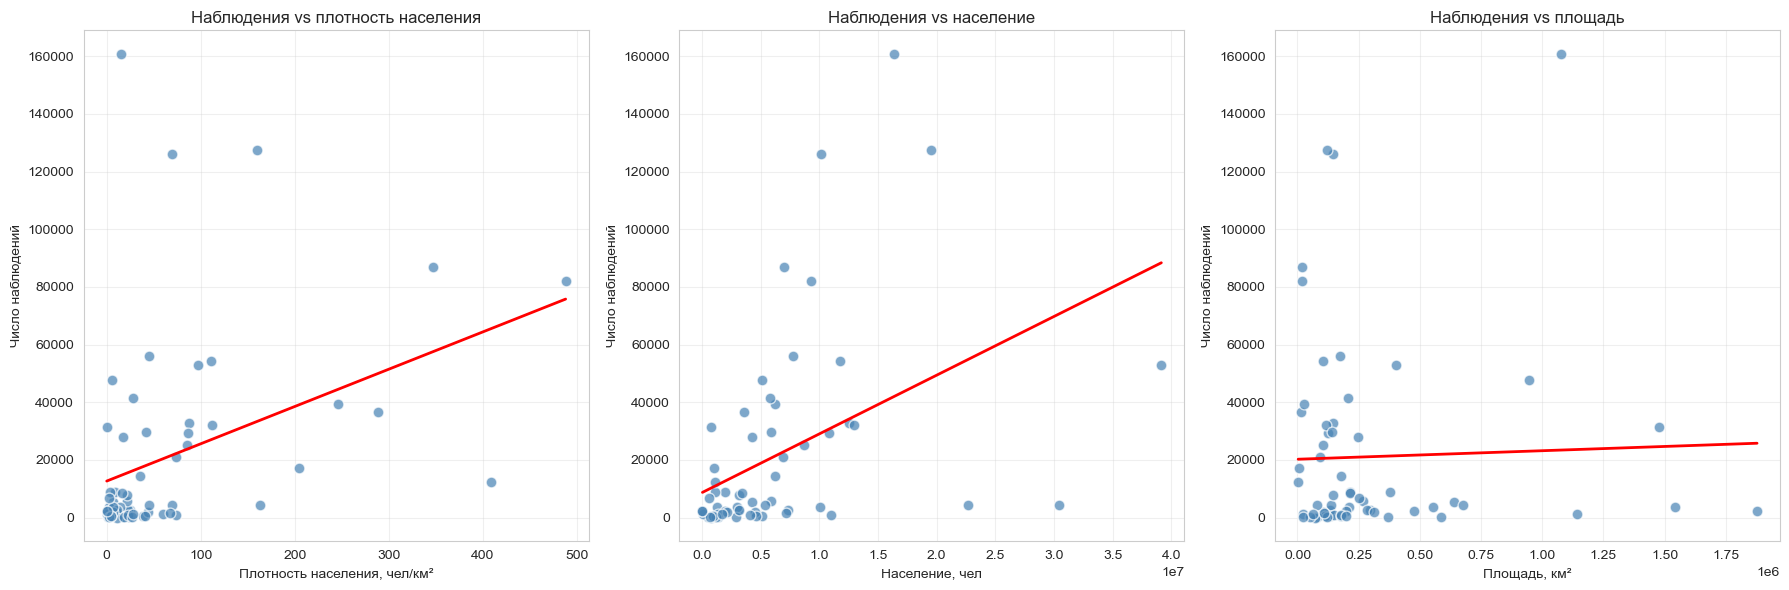

In [60]:
# ============================================================
# Сравнение: наблюдения vs плотность, население, площадь
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pairs = [
    ('плотность', 'Плотность населения, чел/км²', axes[0]),
    ('население', 'Население, чел', axes[1]),
    ('площадь', 'Площадь, км²', axes[2])
]

for col, label, ax in pairs:
    ax.scatter(region_no_dc[col], region_no_dc['наблюдений'],
               s=60, alpha=0.7, color='steelblue', edgecolor='white')
    slope, intercept = np.polyfit(region_no_dc[col],
                                   region_no_dc['наблюдений'], 1)
    x_line = np.linspace(region_no_dc[col].min(),
                         region_no_dc[col].max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color='red', linewidth=2)
    ax.set_xlabel(label)
    ax.set_ylabel('Число наблюдений')
    ax.set_title(f'Наблюдения vs {label.split(",")[0].lower()}', fontsize=12)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Проверка показала, что связь наблюдений с плотностью слабая, а с площадью — отсутствует вовсе. Связь наблюдений с населением — умеренная (Спирмен 0.58), с площадью — отсутствует. Население объясняет лишь часть разброса, поэтому нормализация на такие слабые предикторы не даст устойчивой метрики: она поделит большие числа на произвольные значения и создаст иллюзию точности. Поэтому от нормализации решено отказаться — это была попытка, но данные её не поддерживают.

Этот блок показывает, что связь плотности населения и числа регистраций может отражать как активность наблюдателей, так и особенности распределения птиц. По имеющимся данным разделить вклад этих факторов нельзя.

## Итоговые выводы

1. Подготовлена база для анализа пространственно-временной динамики

В ходе проекта обработаны данные GBIF о наблюдениях за лебедями в США и Канаде за 1980–2023 годы. Из исходных 3 489 498 записей отобраны наблюдения за тремя видами: лебедем-шипуном (Cygnus olor), лебедем-трубачом (Cygnus buccinator) и тундровым лебедем (Cygnus columbianus).

Выполнены очистка и фильтрация данных, унификация названий регионов, присоединение температуры и плотности населения, разделение на зимний и летний сезоны и пять временных периодов. После сезонной фильтрации осталось 1 289 670 исходных наблюдений, объединённых в 70 973 агрегированные записи без пропусков. Количество исходных наблюдений сохранено в столбце observations. Подготовленный датасет сохранён в data_seasonal_enriched.csv.

Таким образом, сформирована информационная основа для сравнения распределения лебедей между годами, сезонами, видами и географическими зонами.

2. Выделены пять географических зон с неодинаковой представленностью наблюдений

Иерархическая кластеризация методом Уорда распределила 1 756 уникальных координатных ячеек между пятью зонами:

• Север — Аляска и север Канады;
• Юг США;
• Северо-восток США и восток Канады;
• Запад США и Канады;
• Центр Канады.

Число уникальных ячеек в кластерах относительно сопоставимо — от 297 до 456, однако количество исходных наблюдений резко различается. На Северо-восток США и восток Канады приходится около 77% всех наблюдений, тогда как на Центр Канады — менее 1%.

Это показывает, что пространственный охват данных неравномерен. Кластеры позволяют анализировать региональные особенности, но не устраняют различий в интенсивности наблюдений.

3. Выявлены статистически значимые временные тренды, но единого направления смещения нет

Простые линейные регрессии показали разнонаправленные изменения широты зарегистрированных наблюдений:

Географическая зонаОбщий тренд, ° широты/годНаправление
Северо-восток США и восток Канады+0,0258На север
Запад США и Канады+0,0136На север
Север — Аляска и север Канады−0,0570На юг
Юг США−0,0269На юг
Центр Канады−0,2534На юг
Все перечисленные тренды статистически значимы в рамках применённых моделей. Однако в четырёх из пяти кластеров год объясняет менее 2% вариации широты. Следовательно, статистическая значимость не означает, что временной тренд является главным фактором пространственного распределения.

Наиболее выраженный общий отрицательный тренд получен для Центра Канады, но его нельзя напрямую интерпретировать как столь же быстрое смещение ареала каждого вида. После разделения по видам и учёта внешних факторов картина существенно меняется.

Основной результат: данные не подтверждают универсальное движение всех лебедей Северной Америки на север или на юг. Выявленные изменения зависят от региона, вида и сезона.

4. Сезонность существенно меняет интерпретацию распределения и трендов

Средняя широта агрегированных записей составляет 41,84° зимой и 47,42° летом — различие равно 5,58°. Летом широтное распределение также более широкое: стандартное отклонение составляет 9,34° против 4,65° зимой. Различие сезонных распределений подтверждено критерием Краскела—Уоллиса: H = 6961,25; p < 0,001.

Сезонная разбивка выявила особенности, которые скрываются в общих трендах:

• На Севере зимний тренд направлен на север (+0,0302°/год), летний — на юг (−0,0375°/год).
• На Западе летом выявлен положительный тренд (+0,0342°/год), а зимой статистически значимый тренд не обнаружен (p = 0,251). Здесь речь идёт не о противоположных направлениях, а о различии выраженности изменений.
• На Северо-востоке общие по видам тренды положительны в оба сезона.

Таким образом, сезонность необходимо учитывать не только при описании распределения птиц, но и при оценке многолетних изменений. При этом различие средних широт между сезонами характеризует выборку наблюдений, а не расстояние миграции отдельных птиц.

5. Виды различаются как по распределению, так и по временной динамике

Критерий Краскела—Уоллиса выявил различия между видами по широте и температуре. Попарные тесты Манна—Уитни показали значимые различия всех трёх пар по широте, температуре и плотности населения регионов наблюдения.

В объединённой сезонной выборке получены следующие медианы:

ВидШиротаТемператураПлотность населения
Лебедь-шипун41°+7,67 °C86 чел./км²
Лебедь-трубач45°+4,22 °C17 чел./км²
Тундровый лебедь42°+1,72 °C45 чел./км²
Следовательно, по медиане широты именно в данной выборке севернее расположен трубач, а не тундровый лебедь. Эти показатели отражают состав зарегистрированных наблюдений и не являются полным описанием экологических ниш видов.

Множественные регрессии с учётом температуры и плотности населения уточнили временные тенденции:

• На Западе у трубача сохраняются противоположные сезонные направления: зимой −0,0379°/год, летом +0,1016°/год.
• У шипуна на Западе отрицательные тренды сохраняются зимой и летом: −0,0981 и −0,0751°/год.
• У тундрового лебедя зимой положительные тренды получены на Юге США и Северо-востоке: +0,0248 и +0,0295°/год.
• На Северо-востоке положительный коэффициент года значим у шипуна и трубача в оба сезона, а у тундрового лебедя — только зимой.
• В Центре Канады летний отрицательный тренд трубача после учёта температуры и плотности населения перестаёт быть статистически значимым (p = 0,127).

Следовательно, объединение видов может скрывать или менять наблюдаемую картину. Некоторые общие тренды могут отражать изменение состава выборки, а не одинаковое перемещение всех видов.

6. Температура связана с широтой наблюдений, но причинное влияние потепления не установлено

В общей выборке линейная корреляция широты и температуры практически отсутствует: r = 0,014. При разделении по сезонам обнаруживается выраженная отрицательная связь:

• зимой — r = −0,592;
• летом — r = −0,869.

Это демонстрирует, насколько смешение сезонных групп способно скрывать пространственные закономерности.

Температура также является статистически значимым предиктором во многих множественных регрессиях, хотя направление связи неодинаково во всех группах. Общая модель объясняет только 6,7% вариации широты, тогда как в отдельных сочетаниях региона, вида и сезона доля объяснённой вариации существенно выше.

Однако температура сама закономерно меняется с широтой. Поэтому полученные связи не доказывают, что климатическое потепление вызвало выявленные временные смещения. Для такого вывода необходимо отдельно анализировать температурные изменения во времени и отделять их от устойчивых географических различий.

7. Обнаружены признаки зависимости данных от человеческой активности

Широта отрицательно связана с плотностью населения: r Пирсона = −0,255; ρ Спирмена = −0,653. На уровне регионов, после исключения округа Колумбия, число наблюдений положительно связано с численностью населения: ρ = 0,580. Значимой связи числа наблюдений с площадью региона не обнаружено.

Эти результаты согласуются с предположением, что доступность территории и активность наблюдателей влияют на представленность регионов в GBIF. Но они не позволяют полностью отделить наблюдательское смещение от реальных особенностей распределения птиц.

Поэтому ни отрицательные коэффициенты плотности, ни большое число записей в густонаселённых регионах нельзя однозначно трактовать как избегание или предпочтение лебедями соседства с человеком. Простое деление числа наблюдений на население или площадь также не обеспечивает корректного учёта наблюдательского усилия.

8. Ограничения исследования

При интерпретации результатов необходимо учитывать следующее:

• Данные GBIF отражают регистрации птиц, а не их численность. Рост числа записей не равнозначен росту популяции.

• Временной охват неравномерен: около 76% исходных сезонных наблюдений приходится на 2016–2023 годы.

• Агрегация лишь частично уменьшает повторяемость данных. Она выполнена с сохранением месяца и региона, поэтому одна координатная ячейка может быть представлена несколькими строками за сезон.

• Зимний период объединяет январь, февраль и декабрь одного календарного года и не соответствует одной непрерывной зимовке. Летний период включает июнь–август; наличие регистрации не означает подтверждённого гнездования.

• Регрессии и тесты выполнены без весов observations. Их объём выборки определяется числом агрегированных строк, а не суммой исходных наблюдений.

• Повторные записи из одних территорий могут быть пространственно и временно зависимыми. Обычные стандартные ошибки и многочисленные проверки без поправки на множественные сравнения могут завышать уверенность в отдельных результатах.

• Температура и плотность населения заданы на уровне административных регионов, а не конкретных водоёмов; плотность населения не меняется по годам в используемом справочнике.

• Округление координат до 1° ограничивает пространственную точность. Ячейки размером 1° имеют неодинаковую физическую площадь. Их количество характеризует представленность регистраций в сетке, а не площадь ареала.

• Летняя регистрация сама по себе не подтверждает гнездование.

• Пять кластеров используются как условные географические зоны. Кластеризация проведена по стандартизованным координатам; расстояния не являются точными географическими расстояниями.

• Различия оценённых наклонов между группами описаны, но не проверены отдельным тестом взаимодействий. Значимость тренда в одной группе и отсутствие значимости в другой ещё не доказывают значимость различия между ними.

• Плотность населения представлена одним временным срезом и характеризует пространственные различия регионов, а не изменение населения за весь период исследования.

• Температура задана на уровне штата или провинции, а не конкретной координатной ячейки. Отрицательная связь температуры с широтой может отражать климатический градиент, а не причинное влияние потепления на распределение птиц.

Общее заключение

В рамках проекта выявлены статистически значимые, но неоднородные изменения широтного распределения наблюдений за лебедями в Северной Америке в 1980–2023 годах. Направление и выраженность изменений зависят от географической зоны, вида и сезона; единого северного или южного тренда для всех лебедей не установлено.

Температура и плотность населения связаны с пространственным распределением записей, однако их причинное влияние на динамику ареалов не доказано. Поэтому цель проекта достигнута на уровне исследовательской оценки распределения наблюдений и связанных с ним факторов. Подтверждение изменения границ ареалов и его причин требует дополнительного анализа с учётом наблюдательского усилия, зависимости записей и изменений видового состава выборки.

## Следующий этап >>

Полученные результаты — это основа для следующего этапа. В отдельном ноутбуке будет выполнена подготовка данных для интерактивного дашборда: экспорт справочников и таблиц фактов, проверка ключей и контрольных сумм. Затем на этих данных в Power BI будет собран одностраничный отчёт, где любой пользователь сможет самостоятельно посмотреть, где и когда наблюдались разные виды лебедей, как менялось распределение по годам и как оно связано с температурой и плотностью населения.